# LCIA and contribution analysis of European hydrogen markets

This notebook compares the **sector-specific low-pressure gaseous hydrogen markets** available for Europe with one generic European hydrogen market. It uses the same Brightway project and prospective database as `LCIA_contribution_analysis_hydrogen_transport.ipynb`.

The functional unit is **1 kg of hydrogen, gaseous, low pressure**. The exact EF 3.1 categories and premise IPCC 2021 GWP100 method are selected in `LCIA_mapping_h2.py`, followed by relative comparisons and upstream process contribution analysis.

In [1]:
import os

os.environ["MKL_THREADING_LAYER"] = "TBB"

## 1. Geography and comparison design

The requested generic comparator is selected at exact ecoinvent location `RER`. In this prospective database, generated sector-specific markets use the IAM region `EUR`, not `RER`. The selection code first looks at `RER` and then uses the explicit `EUR` fallback, printing every selected key and location.

One baseline is retained: **Generic (RER)**, the requested European generic-market comparator. No second generic `EUR` market is included because it has the same modeled supply-chain results in this database.

Only sector markets actually present in the configured database are analyzed. `premise` creates a sector market only where the modeled sector has positive hydrogen demand.

In [2]:
from pathlib import Path
import math
import sys
import warnings

import bw2data as bd
import bw2calc as bc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from premise_gwp import add_premise_gwp

# Resolve shared LCIA modules from the repository root or either example folder.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "examples" / "h2-distribution_LCIA",
    Path.cwd().parent,
]
ANALYSIS_DIR = next(
    (path.resolve() for path in candidate_dirs if (path / "config.py").exists()),
    None,
)
if ANALYSIS_DIR is None:
    raise FileNotFoundError(
        "Run this notebook from the repository root, the h2-distribution_LCIA "
        "folder, or its notebooks folder."
    )
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import config as cfg
import LCIA_mapping_h2 as h2map
from LCIA_mapping_h2 import impact_category_label

pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
    "figure.titlesize": 18,
})

17:51:43+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


In [3]:
list(bd.databases)

[]

## 2. Configuration

The project and database exactly match the source notebook. Change only these constants when deliberately applying the workflow to another prospective database.

In [4]:
PROJECT = "ecoinvent-3.12-cutoff"
DATABASE = 'ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full'
# Operational settings remain in config.py; semantic methods live only in
# LCIA_mapping_h2.py and are shared with every other LCIA notebook.
GENERIC_MARKET_NAME = cfg.GENERIC_MARKET_NAME
REFERENCE_PRODUCT = cfg.REFERENCE_PRODUCT
UNIT = cfg.UNIT
FUNCTIONAL_UNIT_KG = cfg.FUNCTIONAL_UNIT_KG
TARGET_LOCATION = cfg.TARGET_LOCATION
SECTOR_LOCATION_FALLBACKS = cfg.SECTOR_LOCATION_FALLBACKS
TOP_N_PROCESSES = cfg.TOP_N_PROCESSES
EXPECTED_SECTOR_MARKETS = cfg.EXPECTED_SECTOR_MARKETS
PREMISE_GWP_METHOD = h2map.PREMISE_GWP_METHOD

## 3. Open the project and select European market datasets

Selection requires exact activity name, reference product, unit, and location. Duplicate exact matches are treated as errors rather than chosen arbitrarily.

In [5]:
bd.projects.set_current(PROJECT)

# Import/refresh the premise climate methods before selecting LCIA methods.
# PREMISE_GWP_METHOD includes the characterization factor for hydrogen emissions to air.
add_premise_gwp()
if PREMISE_GWP_METHOD not in bd.methods:
    raise LookupError(f"premise_gwp did not install the expected method: {PREMISE_GWP_METHOD}")
if DATABASE not in bd.databases:
    available = "\n".join(f"  - {name}" for name in bd.databases)
    raise KeyError(f"Database {DATABASE!r} is unavailable. Available databases:\n{available}")

database = bd.Database(DATABASE)
print(f"Project:  {bd.projects.current}")
print(f"Database: {database.name} ({len(database):,} activities)")

Using biosphere database: biosphere-3.12 (version (3, 12))
Adding ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: set_biosphere_type
Applying strategy: drop_unspecified_subcategories
Applying strategy: link_iterable_by_fields
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applied 8 strategies in 0.70 seconds
Dropped 47 unlinked lower stratosphere + upper troposphere flows
Wrote 1 LCIA methods with 208 characterization factors
Adding ('IPCC 2021', 'climate change', 'GWP 20a, incl. H and bio CO2')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: set_biosphere_type
Applying strategy: drop_unspecified_subcategor

In [6]:
def exact_matches(name, location):
    return sorted(
        [
            activity for activity in database
            if activity.get("name") == name
            and activity.get("reference product") == REFERENCE_PRODUCT
            and activity.get("unit") == UNIT
            and activity.get("location") == location
        ],
        key=lambda activity: str(activity.key),
    )


def require_one(name, location):
    matches = exact_matches(name, location)
    if len(matches) != 1:
        raise LookupError(
            f"Expected exactly one match for {name!r} at {location!r}; found {len(matches)}."
        )
    return matches[0]


generic_rer = require_one(GENERIC_MARKET_NAME, TARGET_LOCATION)
selected = {"Generic": generic_rer}
sector_locations = {}
missing_sector_labels = []

for label, name in EXPECTED_SECTOR_MARKETS.items():
    chosen = None
    for location in (TARGET_LOCATION, *SECTOR_LOCATION_FALLBACKS):
        matches = exact_matches(name, location)
        if len(matches) > 1:
            raise LookupError(f"Multiple exact matches for {name!r} at {location!r}.")
        if matches:
            chosen = matches[0]
            break
    if chosen is None:
        missing_sector_labels.append(label)
    else:
        selected[label] = chosen
        sector_locations[label] = chosen.get("location")

if len(selected) == 1:
    raise LookupError("No European sector-specific hydrogen markets were found.")
if missing_sector_labels:
    warnings.warn(
        "No market was generated for these European sectors in this scenario: "
        + ", ".join(missing_sector_labels)
    )

fallback_locations_used = sorted(set(sector_locations.values()) - {TARGET_LOCATION})
if fallback_locations_used:
    warnings.warn(
        f"Sector markets are unavailable at {TARGET_LOCATION}; using mapped IAM location(s) "
        f"{fallback_locations_used}."
    )

selection_rows = [
    {
        "comparison label": label,
        "name": activity.get("name"),
        "reference product": activity.get("reference product"),
        "location": activity.get("location"),
        "unit": activity.get("unit"),
        "database key": activity.key,
    }
    for label, activity in selected.items()
]
selection_df = pd.DataFrame(selection_rows)
display(selection_df)

C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\2845316801.py:46: UserWarning: No market was generated for these European sectors in this scenario: Steel, Cement, Heating, Other end uses
  warnings.warn(
C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\2845316801.py:53: UserWarning: Sector markets are unavailable at RER; using mapped IAM location(s) ['EUR'].
  warnings.warn(


,comparison label,name,reference product,location,unit,database key
0,Generic,"market for hydrogen, gaseous, low pressure","hydrogen, gaseous, low pressure",RER,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, ade5d1e1914741479162ef4f94132a04)"
1,Transport,"market for hydrogen, gaseous, low pressure, for transport","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 70aeb498044d494c8191b1c55851bbbb)"
2,Chemicals,"market for hydrogen, gaseous, low pressure, for chemicals","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, c3be014d0ba14f0f863b843afe9d3145)"


### Finalize the comparison order

The requested generic `RER` market is followed by every sector-specific European market available in the configured database.

In [7]:
sector_order = [label for label in EXPECTED_SECTOR_MARKETS if label in selected]
market_order = ["Generic", *sector_order]

selection_df = pd.DataFrame([
    {
        "comparison label": label,
        "name": activity.get("name"),
        "reference product": activity.get("reference product"),
        "location": activity.get("location"),
        "unit": activity.get("unit"),
        "database key": activity.key,
    }
    for label, activity in selected.items()
])
display(selection_df)

,comparison label,name,reference product,location,unit,database key
0,Generic,"market for hydrogen, gaseous, low pressure","hydrogen, gaseous, low pressure",RER,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, ade5d1e1914741479162ef4f94132a04)"
1,Transport,"market for hydrogen, gaseous, low pressure, for transport","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 70aeb498044d494c8191b1c55851bbbb)"
2,Chemicals,"market for hydrogen, gaseous, low pressure, for chemicals","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, c3be014d0ba14f0f863b843afe9d3145)"


## 4. Select the canonical LCIA methods

Only the exact method tuples declared in `LCIA_mapping_h2.METHOD_LABELS` are included. The hydrogen-inclusive premise method contains the characterization factor for hydrogen emissions to air; every category retains its own physical unit.

In [8]:
# Use the same exact method set as the master and multi-IAM notebooks.
lcia_methods = list(h2map.SELECTED_METHODS)
CONTRIBUTION_METHODS = list(h2map.CONTRIBUTION_METHODS)
missing_methods = [method for method in lcia_methods if method not in bd.methods]
if missing_methods:
    raise LookupError(f"Configured LCIA methods are unavailable: {missing_methods}")
ef31_methods = [method for method in lcia_methods if method[0] == "EF v3.1"]

method_rows = []
for method in lcia_methods:
    metadata = bd.Method(method).metadata
    method_rows.append({
        "method": method,
        "impact category": impact_category_label(method),
        "indicator": method[-1],
        "unit": metadata.get("unit", ""),
    })
methods_df = pd.DataFrame(method_rows)
print(
    f"Selected {len(lcia_methods)} methods from LCIA_mapping_h2.py"
)
display(methods_df)

Selected 25 EF 3.1 impact categories, ('IPCC 2021', 'climate change', 'GWP 100a, incl. H')


,method,impact category,indicator,unit
0,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,accumulated exceedance (AE),mol H+-Eq
1,"(EF v3.1, climate change, global warming potential (GWP100))",climate change,global warming potential (GWP100),kg CO2-Eq
2,"(EF v3.1, climate change: biogenic, global warming potential (GWP100))",climate change: biogenic,global warming potential (GWP100),kg CO2-Eq
3,"(EF v3.1, climate change: fossil, global warming potential (GWP100))",climate change: fossil,global warming potential (GWP100),kg CO2-Eq
4,"(EF v3.1, climate change: land use and land use change, global warming potential (GWP100))",climate change: land use and land use change,global warming potential (GWP100),kg CO2-Eq
5,"(EF v3.1, ecotoxicity: freshwater, comparative toxic unit for ecosystems (CTUe))",ecotoxicity: freshwater,comparative toxic unit for ecosystems (CTUe),CTUe
6,"(EF v3.1, ecotoxicity: freshwater, inorganics, comparative toxic unit for ecosystems (CTUe))","ecotoxicity: freshwater, inorganics",comparative toxic unit for ecosystems (CTUe),CTUe
7,"(EF v3.1, ecotoxicity: freshwater, organics, comparative toxic unit for ecosystems (CTUe))","ecotoxicity: freshwater, organics",comparative toxic unit for ecosystems (CTUe),CTUe
8,"(EF v3.1, energy resources: non-renewable, abiotic depletion potential (ADP): fossil fuels)",energy resources: non-renewable,abiotic depletion potential (ADP): fossil fuels,"MJ, net calorific value"
9,"(EF v3.1, eutrophication: freshwater, fraction of nutrients reaching freshwater end compartment (P))",eutrophication: freshwater,fraction of nutrients reaching freshwater end compartment (P),kg P-Eq


## 5. Calculate LCIA scores and premise-GWP process contributions

For each 1 kg market demand, Brightway solves the technosphere system once and switches among all methods selected in `LCIA_mapping_h2.py`. Process contributions are calculated only for its configured contribution method. The characterized inventory is summed by technosphere column and processes are ranked by absolute score, retaining negative credits.

In [9]:
def reverse_activity_index(lca):
    if hasattr(lca, "dicts") and hasattr(lca.dicts, "activity"):
        reverse = lca.dicts.activity.reversed
        return dict(reverse) if not isinstance(reverse, dict) else reverse
    if hasattr(lca, "activity_dict"):
        return {index: key for key, index in lca.activity_dict.items()}
    raise AttributeError("Could not find the Brightway activity index on the LCA object.")


def get_activity_from_key(key):
    try:
        return bd.get_activity(key)
    except Exception:
        return bd.get_node(id=key)


def top_process_rows(lca, market_label, activity, method, unit, top_n):
    process_scores = np.asarray(lca.characterized_inventory.sum(axis=0)).ravel()
    reverse = reverse_activity_index(lca)
    nonzero = np.flatnonzero(process_scores)
    ordered = nonzero[np.argsort(np.abs(process_scores[nonzero]))[::-1]]
    kept = ordered[:top_n]
    rows = []
    for rank, column in enumerate(kept, start=1):
        process = get_activity_from_key(reverse[int(column)])
        score = float(process_scores[column])
        rows.append({
            "market": market_label,
            "market location": activity.get("location"),
            "impact category": impact_category_label(method),
            "indicator": method[-1],
            "method": method,
            "unit": unit,
            "rank": rank,
            "process": process.get("name", str(process)),
            "process location": process.get("location", ""),
            "process key": process.key,
            "score": score,
            "share (%)": 100.0 * score / lca.score if lca.score != 0 else np.nan,
        })
    other_score = float(process_scores.sum() - process_scores[kept].sum())
    rows.append({
        "market": market_label,
        "market location": activity.get("location"),
        "impact category": impact_category_label(method),
        "indicator": method[-1],
        "method": method,
        "unit": unit,
        "rank": top_n + 1,
        "process": "Other",
        "process location": "",
        "process key": None,
        "score": other_score,
        "share (%)": 100.0 * other_score / lca.score if lca.score != 0 else np.nan,
    })
    return rows

In [10]:
score_records = []
contribution_records = []
method_units = {row["method"]: row["unit"] for row in method_rows}

for market_label, activity in selected.items():
    lca = bc.LCA({activity: FUNCTIONAL_UNIT_KG}, lcia_methods[0])
    lca.lci()
    for method in lcia_methods:
        lca.switch_method(method)
        lca.lcia()
        unit = method_units[method]
        score_records.append({
            "market": market_label,
            "market name": activity.get("name"),
            "location": activity.get("location"),
            "impact category": impact_category_label(method),
            "indicator": method[-1],
            "method": method,
            "unit": unit,
            "score per kg H2": float(lca.score),
        })
        if method in CONTRIBUTION_METHODS:
            contribution_records.extend(
                top_process_rows(lca, market_label, activity, method, unit, TOP_N_PROCESSES)
            )
    print(f"Finished {market_label} [{activity.get('location')}]")

scores_df = pd.DataFrame(score_records)
contributions_df = pd.DataFrame(contribution_records)
categories = scores_df["impact category"].drop_duplicates().tolist()
display(scores_df.head())

Finished Generic [RER]
Finished Transport [EUR]
Finished Chemicals [EUR]


,market,market name,location,impact category,indicator,method,unit,score per kg H2
0,Generic,"market for hydrogen, gaseous, low pressure",RER,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.021739
1,Generic,"market for hydrogen, gaseous, low pressure",RER,climate change,global warming potential (GWP100),"(EF v3.1, climate change, global warming potential (GWP100))",kg CO2-Eq,1.815010
2,Generic,"market for hydrogen, gaseous, low pressure",RER,climate change: biogenic,global warming potential (GWP100),"(EF v3.1, climate change: biogenic, global warming potential (GWP100))",kg CO2-Eq,0.007309
3,Generic,"market for hydrogen, gaseous, low pressure",RER,climate change: fossil,global warming potential (GWP100),"(EF v3.1, climate change: fossil, global warming potential (GWP100))",kg CO2-Eq,1.789118
4,Generic,"market for hydrogen, gaseous, low pressure",RER,climate change: land use and land use change,global warming potential (GWP100),"(EF v3.1, climate change: land use and land use change, global warming potential (GWP100))",kg CO2-Eq,0.018583


### Quality-control checks

The top-process rows plus the exact `Other` remainder must reconstruct every total LCIA score. The calculation also verifies one result per selected market and EF method.

In [11]:
expected_result_count = len(selected) * len(lcia_methods)
if len(scores_df) != expected_result_count:
    raise AssertionError(f"Expected {expected_result_count} LCIA results; found {len(scores_df)}.")

reconstructed = (
    contributions_df.groupby(["market", "method"], as_index=False)["score"].sum()
    .rename(columns={"score": "reconstructed score"})
)
expected_contribution_results = len(selected) * len(CONTRIBUTION_METHODS)
if len(reconstructed) != expected_contribution_results:
    raise AssertionError(
        f"Expected {expected_contribution_results} contribution results; found {len(reconstructed)}."
    )
check_df = (
    scores_df[scores_df["method"].isin(CONTRIBUTION_METHODS)]
    .merge(reconstructed, on=["market", "method"], validate="one_to_one")
)
check_df["absolute difference"] = (
    check_df["score per kg H2"] - check_df["reconstructed score"]
).abs()
tolerance = 1e-9 * np.maximum(1.0, check_df["score per kg H2"].abs())
if not np.all(check_df["absolute difference"] <= tolerance):
    raise AssertionError("Process contributions do not reconstruct one or more LCIA totals.")
print(f"All {len(check_df)} contribution totals reconstruct their LCIA scores.")

All 3 contribution totals reconstruct their LCIA scores.


## 6. Compare absolute LCIA impacts per kg H2

Each subplot is one canonically selected LCIA category with its own unit. Bars are comparable within a subplot only.

C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\2535195422.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


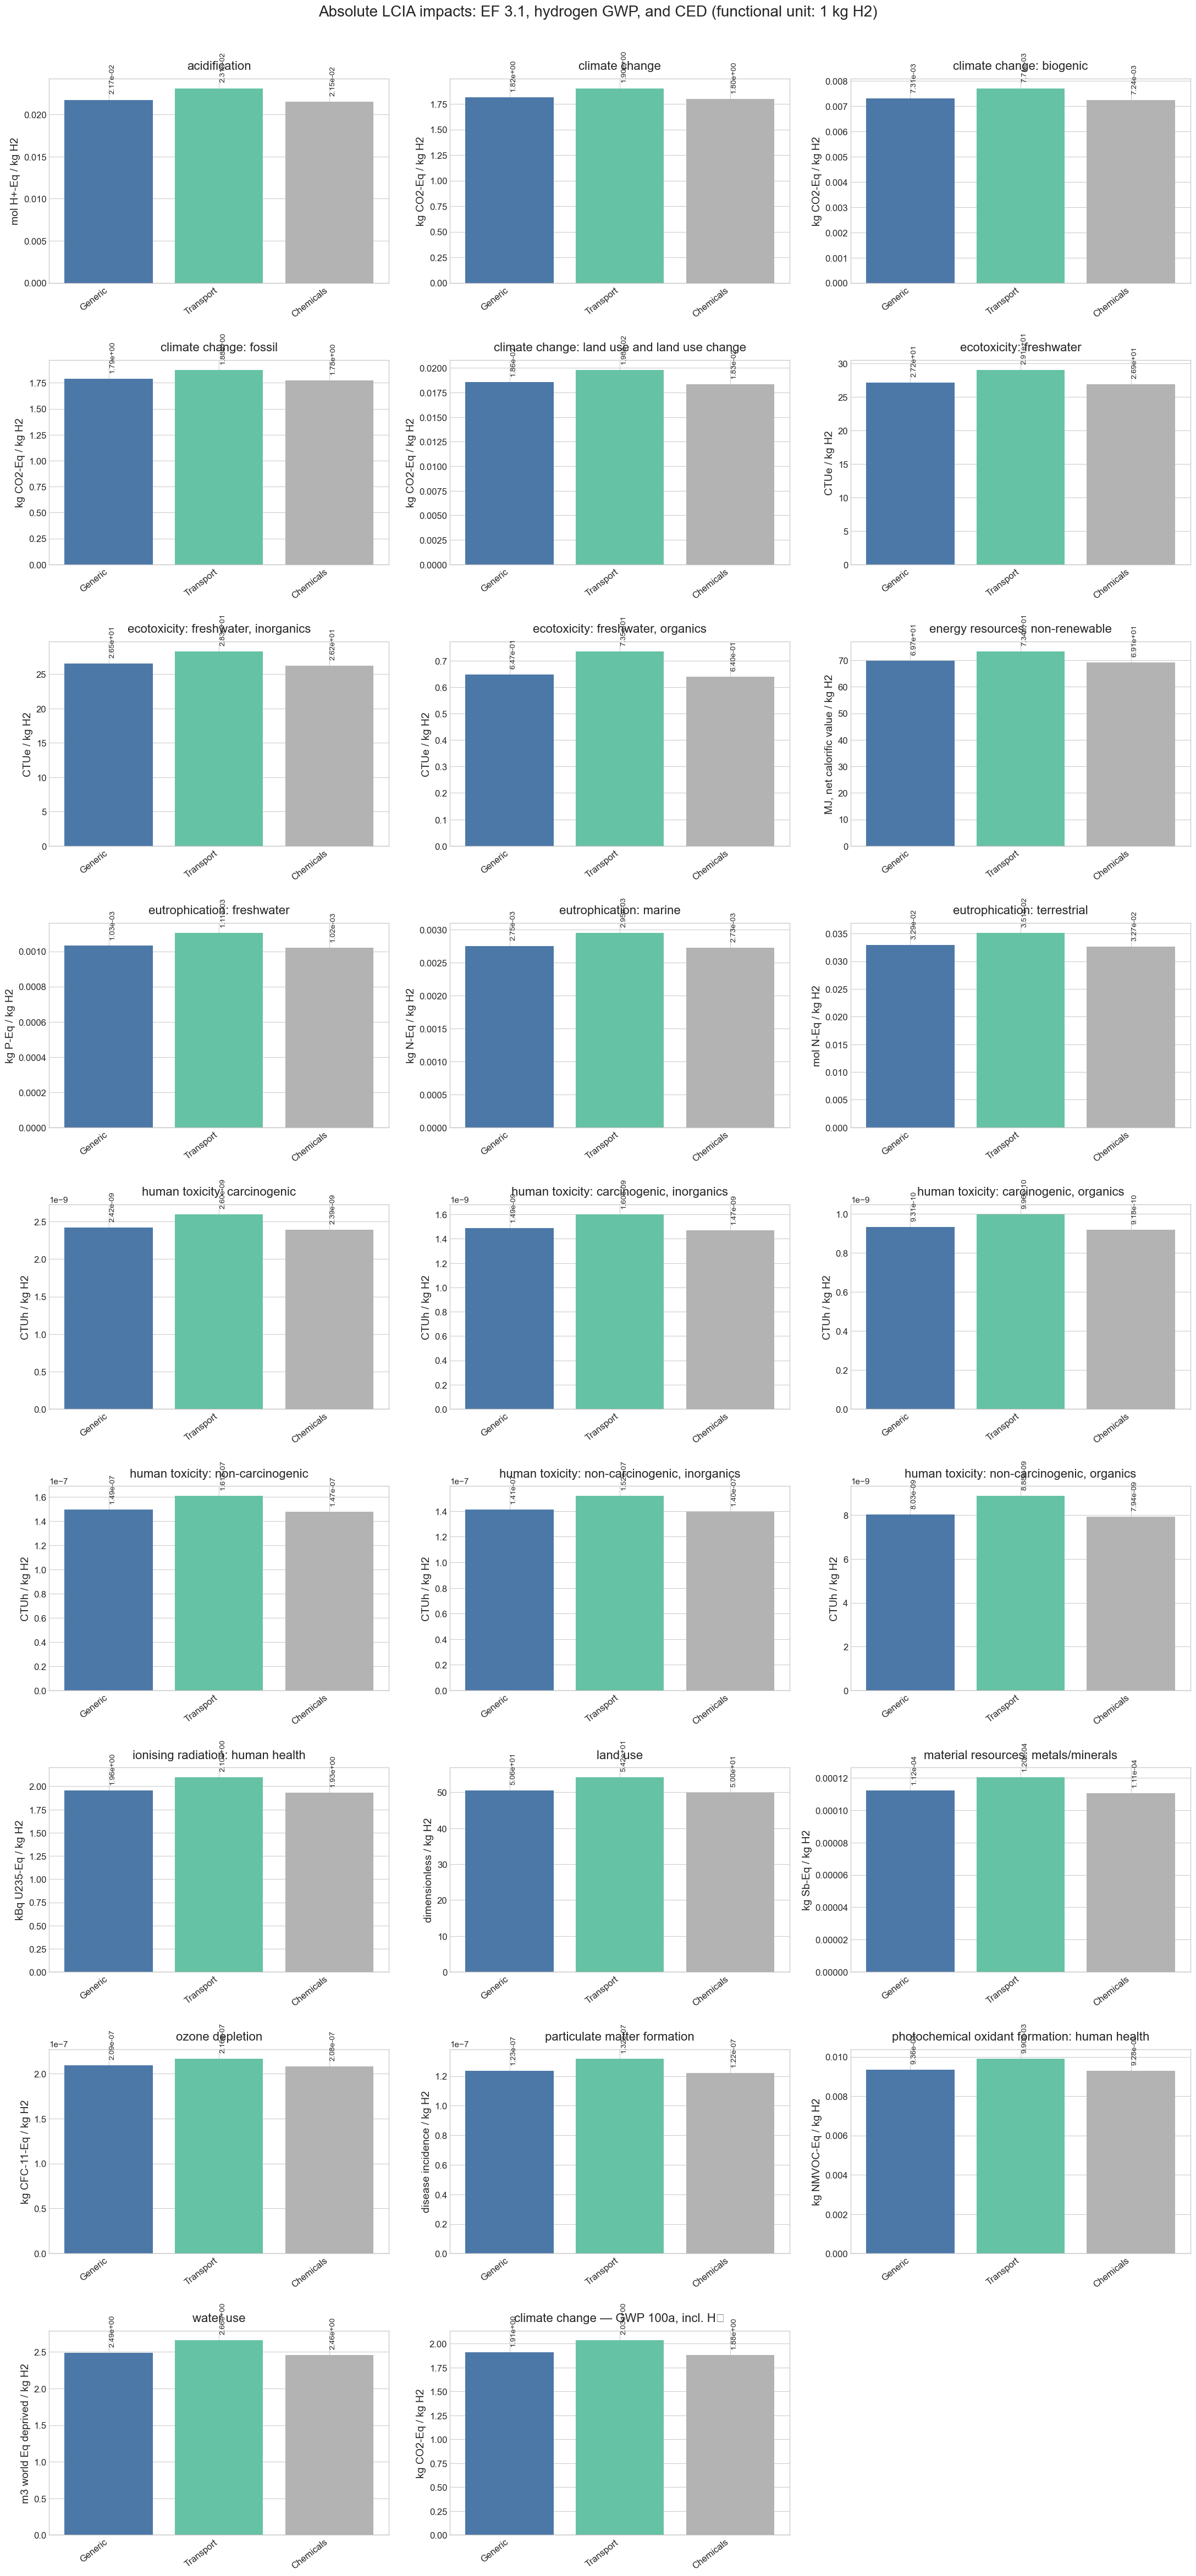

In [12]:
ncols = 3
nrows = math.ceil(len(categories) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.2 * nrows), squeeze=False)
colors = ["#4c78a8", *plt.get_cmap("Set2")(np.linspace(0, 1, max(len(sector_order), 1)))]
for ax, category in zip(axes.ravel(), categories):
    subset = (
        scores_df[scores_df["impact category"] == category]
        .set_index("market")
        .reindex(market_order)
    )
    values = subset["score per kg H2"].to_numpy(dtype=float)
    bars = ax.bar(np.arange(len(market_order)), values, color=colors[:len(market_order)])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(category, fontsize=16, pad=12)
    ax.set_ylabel(f"{subset['unit'].iloc[0]} / kg H2", fontsize=14)
    ax.set_xticks(np.arange(len(market_order)), market_order, rotation=38, ha="right", fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    for bar, value in zip(bars, values):
        ax.annotate(
            f"{value:.2e}",
            (bar.get_x() + bar.get_width() / 2, value),
            xytext=(5, 10 if value >= 0 else -12),
            textcoords="offset points", ha="center", fontsize=10, rotation=90,
        )
    nonzero_abs = np.abs(values[np.isfinite(values) & (values != 0)])
    if len(nonzero_abs) and nonzero_abs.max() / nonzero_abs.min() > 1_000:
        ax.set_yscale("symlog", linthresh=max(nonzero_abs.min(), 1e-30))

for ax in axes.ravel()[len(categories):]:
    ax.set_visible(False)
fig.suptitle("Absolute impacts for the canonical LCIA methods (functional unit: 1 kg H2)", fontsize=20, y=1.002)
fig.tight_layout()
#plt.show()

## 7. Difference from the requested generic RER market

Absolute and percentage differences use the single `Generic (RER)` market as the baseline. Percentage differences are undefined when the generic score is zero.

In [13]:
def comparison_to_baseline(baseline_label, comparison_labels):
    baseline = (
        scores_df[scores_df["market"] == baseline_label]
        [["method", "score per kg H2"]]
        .rename(columns={"score per kg H2": "baseline score per kg H2"})
    )
    compared = scores_df[scores_df["market"].isin(comparison_labels)].merge(
        baseline, on="method", validate="many_to_one"
    )
    compared["absolute difference"] = (
        compared["score per kg H2"] - compared["baseline score per kg H2"]
    )
    compared["difference (%)"] = np.where(
        compared["baseline score per kg H2"] != 0,
        100.0 * compared["absolute difference"] / compared["baseline score per kg H2"],
        np.nan,
    )
    compared["baseline"] = baseline_label
    return compared


comparison_rer_df = comparison_to_baseline("Generic", sector_order)
display(comparison_rer_df[[
    "market", "location", "impact category", "unit",
    "score per kg H2", "baseline score per kg H2",
    "absolute difference", "difference (%)",
]])

,market,location,impact category,unit,score per kg H2,baseline score per kg H2,absolute difference,difference (%)
0,Transport,EUR,acidification,mol H+-Eq,2.310763e-02,2.173892e-02,1.368716e-03,6.296154
1,Transport,EUR,climate change,kg CO2-Eq,1.903277e+00,1.815010e+00,8.826663e-02,4.863148
2,Transport,EUR,climate change: biogenic,kg CO2-Eq,7.708419e-03,7.308717e-03,3.997020e-04,5.468839
3,Transport,EUR,climate change: fossil,kg CO2-Eq,1.875744e+00,1.789118e+00,8.662648e-02,4.841854
4,Transport,EUR,climate change: land use and land use change,kg CO2-Eq,1.982390e-02,1.858346e-02,1.240442e-03,6.674982
5,Transport,EUR,ecotoxicity: freshwater,CTUe,2.905298e+01,2.715849e+01,1.894481e+00,6.975648
6,Transport,EUR,"ecotoxicity: freshwater, inorganics",CTUe,2.831757e+01,2.651119e+01,1.806380e+00,6.813651
7,Transport,EUR,"ecotoxicity: freshwater, organics",CTUe,7.354069e-01,6.473059e-01,8.810102e-02,13.610415
8,Transport,EUR,energy resources: non-renewable,"MJ, net calorific value",7.340545e+01,6.974008e+01,3.665368e+00,5.255755
9,Transport,EUR,eutrophication: freshwater,kg P-Eq,1.105375e-03,1.032512e-03,7.286289e-05,7.056858


C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\3749344030.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


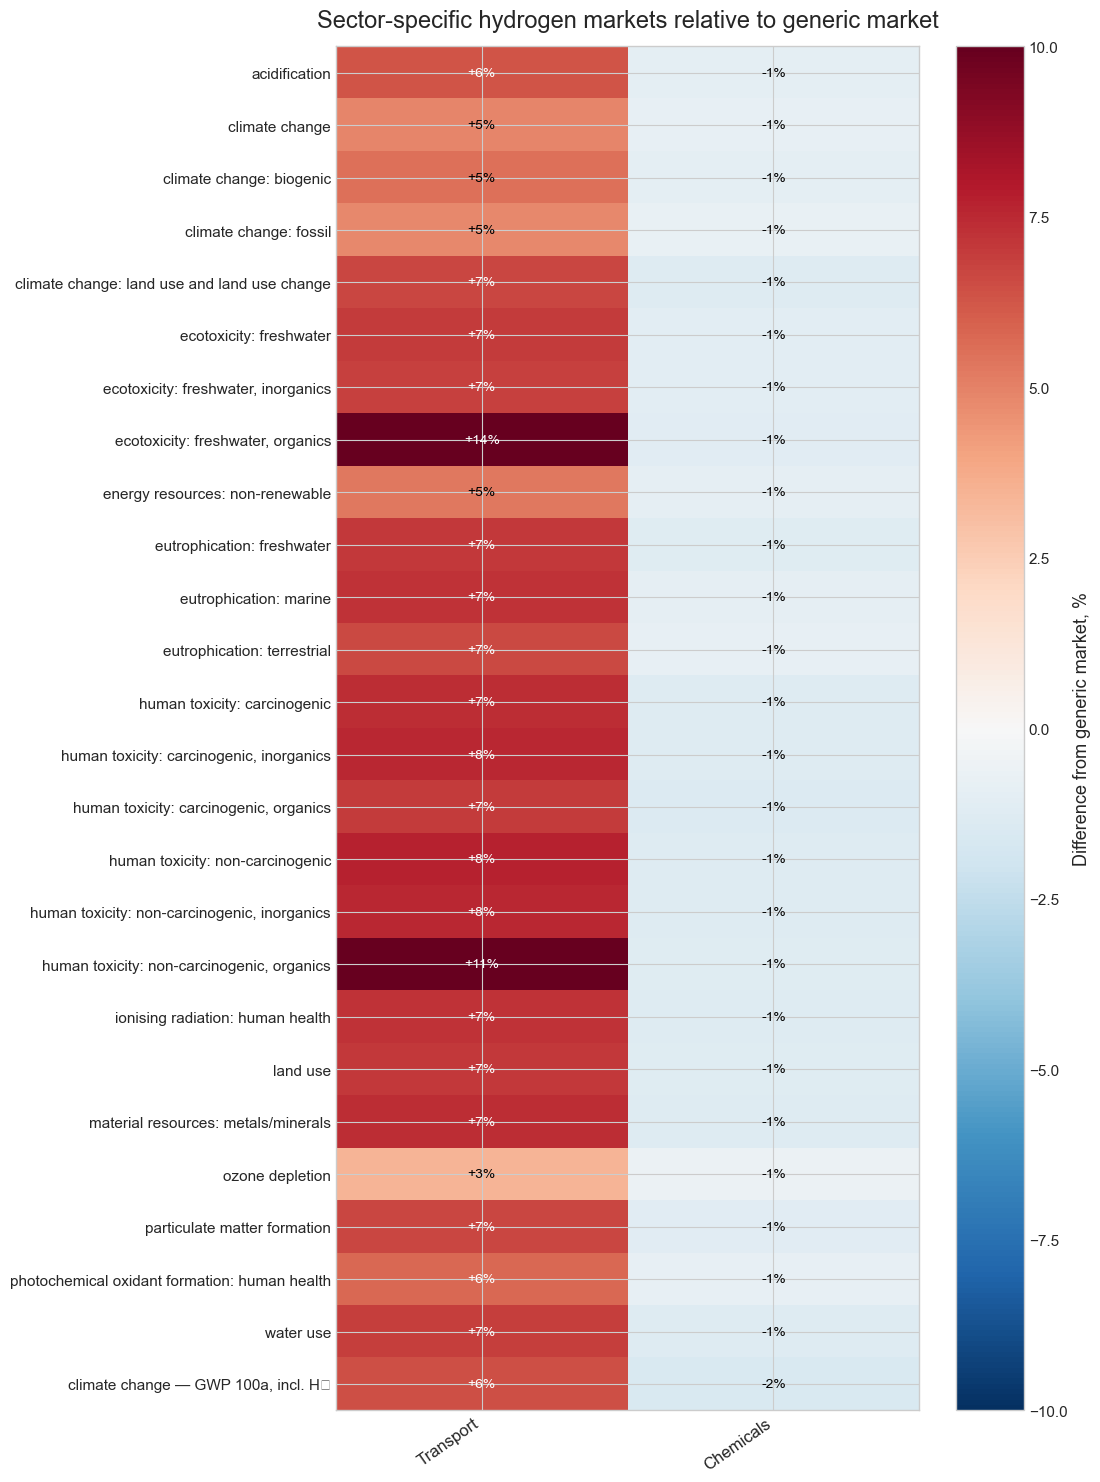

In [14]:
difference_matrix = (
    comparison_rer_df.pivot(index="impact category", columns="market", values="difference (%)")
    .reindex(index=categories, columns=sector_order)
)
finite_values = difference_matrix.to_numpy(dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]
color_limit = max(10.0, np.percentile(np.abs(finite_values), 95)) if len(finite_values) else 100.0

fig, ax = plt.subplots(figsize=(max(11, 2.0 * len(sector_order)), max(9, 0.58 * len(categories))))
image = ax.imshow(
    difference_matrix.to_numpy(), cmap="RdBu_r",
    vmin=-color_limit, vmax=color_limit, aspect="auto",
)
ax.set_xticks(np.arange(len(sector_order)), sector_order, rotation=35, ha="right", fontsize=12)
ax.set_yticks(np.arange(len(categories)), categories, fontsize=11)
for i in range(difference_matrix.shape[0]):
    for j in range(difference_matrix.shape[1]):
        value = difference_matrix.iat[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:+.0f}%", ha="center", va="center", fontsize=10,
                    color="white" if abs(value) > 0.55 * color_limit else "black")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Difference from generic market, %", fontsize=13)
colorbar.ax.tick_params(labelsize=11)
ax.set_title("Sector-specific hydrogen markets relative to generic market", fontsize=17, pad=14)
fig.tight_layout()
plt.show()

## 8. Selected-impact hotspot analysis by process group

The hotspot analysis retains ten decision-relevant impact categories. Each panel reports absolute contributions in its own method unit per kg H2 and uses the Layer 1 process groups defined below: individual hydrogen production technologies and aggregated hydrogen distribution. Only transport-related hydrogen and ammonia emissions are classified as leakage. Percentage labels are signed shares of the corresponding market total; positive and negative contributions are stacked separately so credits remain visible. Values and axes must not be compared numerically across impact categories with different units.

In [15]:
# Hotspot categories follow the same order as the canonical method list.
HOTSPOT_IMPACT_CATEGORY_ORDER = list(h2map.SPECIFIC_IMPACT_CATEGORY_ORDER)

The following cell performs the hotspot process-group calculation and reconciliation for the shared category list.


Finished hotspot process-group analysis: acidification
Finished hotspot process-group analysis: climate change — GWP 100a, incl. H₂
Finished hotspot process-group analysis: ecotoxicity: freshwater
Finished hotspot process-group analysis: energy resources: non-renewable
Finished hotspot process-group analysis: eutrophication: freshwater
Finished hotspot process-group analysis: eutrophication: marine
Finished hotspot process-group analysis: human toxicity: carcinogenic
Finished hotspot process-group analysis: human toxicity: non-carcinogenic
Finished hotspot process-group analysis: material resources: metals/minerals
Finished hotspot process-group analysis: particulate matter formation


C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\2923092500.py:181: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout(rect=(0, 0, 0.83, 0.98))
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


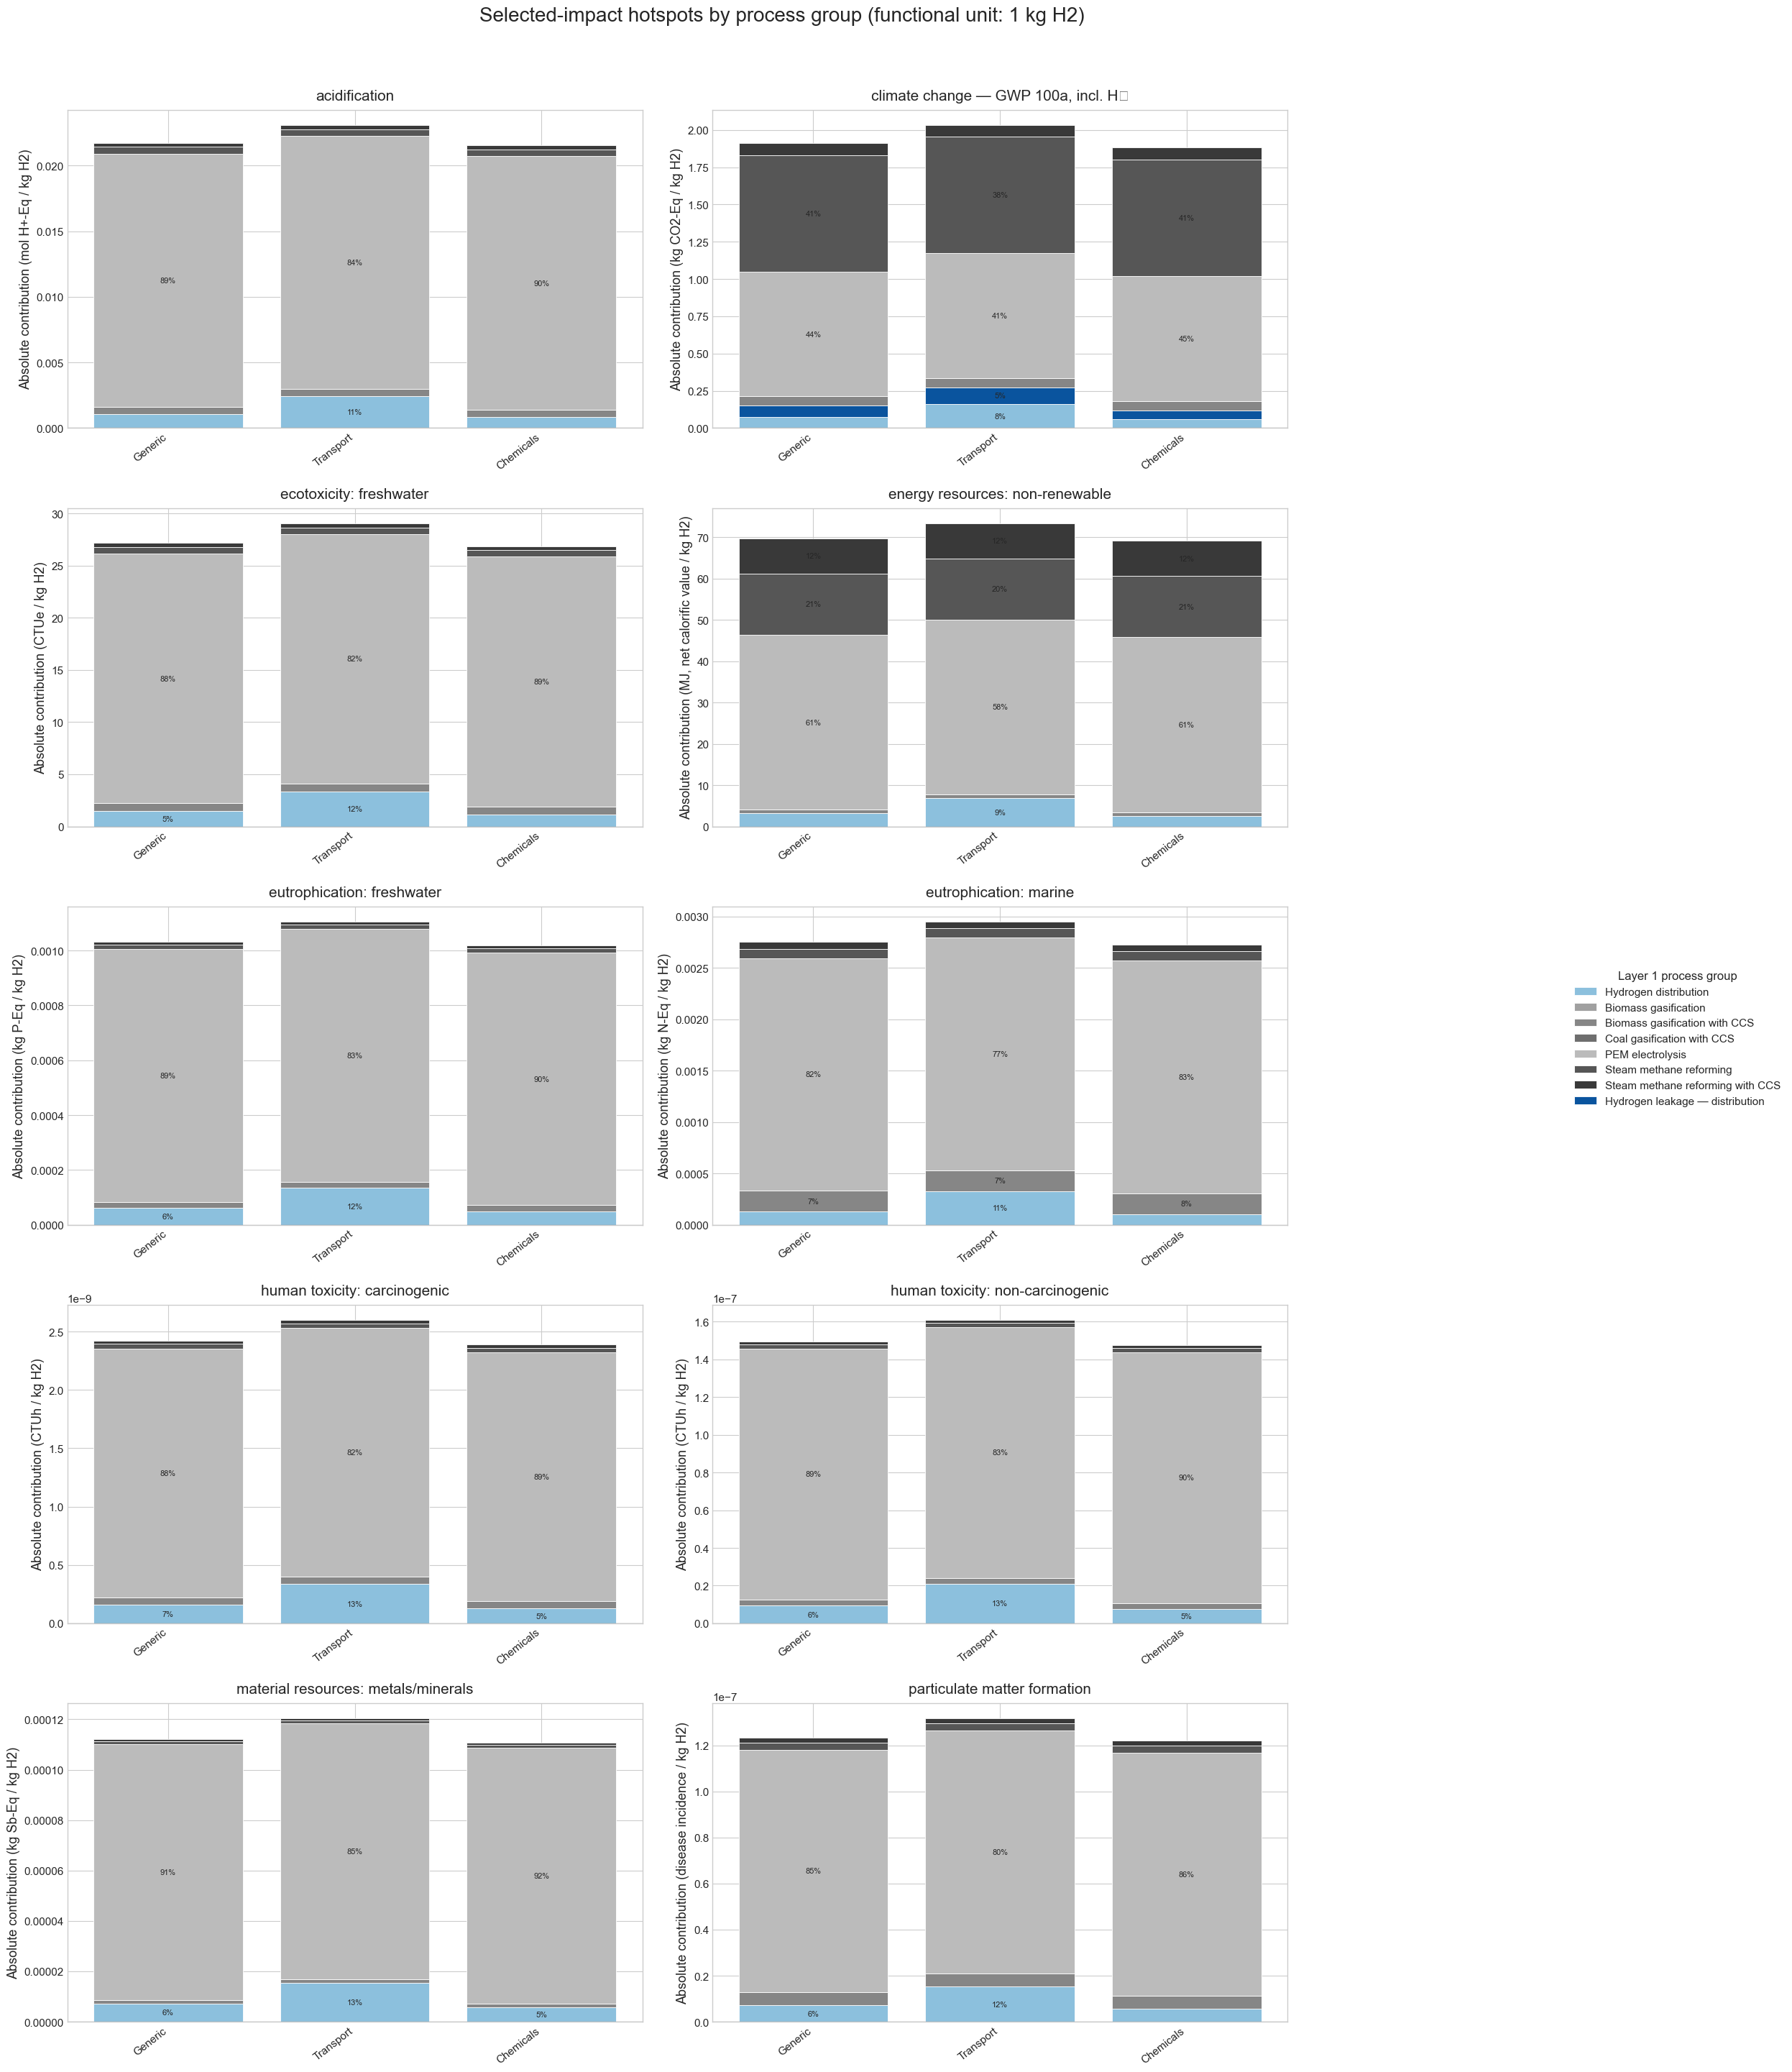

In [16]:
import importlib
import sys

# Calculation helpers remain separate; their mappings come from LCIA_mapping_h2.py.
stage_module_dir = ANALYSIS_DIR / "notebooks"
if str(stage_module_dir) not in sys.path:
    sys.path.insert(0, str(stage_module_dir))
import lcia_stage_analysis as stage_analysis
importlib.reload(stage_analysis)

hotspot_method_candidates = [*ef31_methods, PREMISE_GWP_METHOD]
hotspot_methods_by_category = {}
for category in HOTSPOT_IMPACT_CATEGORY_ORDER:
    matches = [
        method for method in hotspot_method_candidates
        if impact_category_label(method) == category
    ]
    if len(matches) != 1:
        raise LookupError(
            f"Expected exactly one LCIA method for hotspot category {category!r}; "
            f"found {len(matches)}: {matches}"
        )
    hotspot_methods_by_category[category] = matches[0]

hotspot_layer1_frames = []
hotspot_distribution_frames = []
hotspot_reconciliation_frames = []
for category, method in hotspot_methods_by_category.items():
    result = stage_analysis.analyze_hydrogen_life_cycle_stages(
        selected=selected,
        market_order=market_order,
        method=method,
        functional_unit=FUNCTIONAL_UNIT_KG,
        scores_df=scores_df,
        impact_category=category,
        unit=method_units[method],
        reconciliation_rtol=1e-5,
    )
    hotspot_layer1_frames.append(result["layer1"])
    hotspot_distribution_frames.append(result["distribution processes"])
    hotspot_reconciliation_frames.append(result["reconciliation"])
    print(f"Finished hotspot process-group analysis: {category}")

hotspot_layer1_df = pd.concat(hotspot_layer1_frames, ignore_index=True)
hotspot_distribution_df = pd.concat(
    hotspot_distribution_frames, ignore_index=True
)
hotspot_reconciliation_df = pd.concat(
    hotspot_reconciliation_frames, ignore_index=True
)
hotspot_process_group_df = (
    hotspot_layer1_df.groupby(
        [
            "market", "method", "impact category", "unit",
            "layer 1 group", "component",
        ],
        as_index=False,
        dropna=False,
    )["score"].sum()
    .rename(columns={"score": "absolute contribution"})
)
hotspot_totals_df = (
    scores_df[scores_df["method"].isin(hotspot_methods_by_category.values())]
    [["market", "method", "score per kg H2"]]
)
hotspot_process_group_df = hotspot_process_group_df.merge(
    hotspot_totals_df,
    on=["market", "method"],
    validate="many_to_one",
)
hotspot_process_group_df["share of total impact (%)"] = np.where(
    hotspot_process_group_df["score per kg H2"] != 0,
    100.0
    * hotspot_process_group_df["absolute contribution"]
    / hotspot_process_group_df["score per kg H2"],
    np.nan,
)
hotspot_process_group_df["impact category"] = pd.Categorical(
    hotspot_process_group_df["impact category"],
    categories=HOTSPOT_IMPACT_CATEGORY_ORDER,
    ordered=True,
)
hotspot_process_group_df = hotspot_process_group_df.sort_values(
    ["impact category", "market", "layer 1 group", "component"]
).reset_index(drop=True)

#display(hotspot_process_group_df)
#display(hotspot_reconciliation_df)

process_group_order = hotspot_process_group_df["component"].drop_duplicates().tolist()
process_group_colors = stage_analysis.stage_layer1_color_map(
    hotspot_layer1_df
)

ncols = 2
nrows = math.ceil(len(HOTSPOT_IMPACT_CATEGORY_ORDER) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(22, 5.8 * nrows),
    squeeze=False,
)
for ax, category in zip(axes.ravel(), HOTSPOT_IMPACT_CATEGORY_ORDER):
    subset = hotspot_process_group_df[
        hotspot_process_group_df["impact category"] == category
    ]
    x = np.arange(len(market_order))
    positive_bottom = np.zeros(len(market_order))
    negative_bottom = np.zeros(len(market_order))
    totals = (
        subset.groupby("market")["score per kg H2"]
        .first()
        .reindex(market_order)
        .to_numpy(dtype=float)
    )

    for component in process_group_order:
        values = (
            subset[subset["component"] == component]
            .groupby("market")["absolute contribution"]
            .sum()
            .reindex(market_order, fill_value=0.0)
            .to_numpy(dtype=float)
        )
        if not np.any(values):
            continue
        bottom = np.where(values >= 0, positive_bottom, negative_bottom)
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            color=process_group_colors[component],
            edgecolor="white",
            linewidth=0.6,
            label=component,
        )
        shares = np.divide(
            100.0 * values,
            totals,
            out=np.full_like(values, np.nan),
            where=totals != 0,
        )
        for bar, value, share, start in zip(bars, values, shares, bottom):
            if np.isfinite(share) and abs(share) >= 5.0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    start + value / 2,
                    f"{share:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        positive_bottom += np.where(values >= 0, values, 0.0)
        negative_bottom += np.where(values < 0, values, 0.0)

    unit = subset["unit"].iloc[0]
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(category, fontsize=15, pad=10)
    ax.set_ylabel(f"Absolute contribution ({unit} / kg H2)")
    ax.set_xticks(x, market_order, rotation=38, ha="right")

for ax in axes.ravel()[len(HOTSPOT_IMPACT_CATEGORY_ORDER):]:
    ax.set_visible(False)

legend_handles = {}
for ax in axes.ravel():
    for handle, label in zip(*ax.get_legend_handles_labels()):
        legend_handles.setdefault(label, handle)
fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    title="Layer 1 process group",
    bbox_to_anchor=(0.995, 0.5),
    loc="center left",
    frameon=False,
)
fig.suptitle(
    "Selected-impact hotspots by process group (functional unit: 1 kg H2)",
    fontsize=20,
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 0.83, 0.98))
plt.show()

,market,method,impact category,unit,substage,process,contribution type,absolute contribution,hydrogen distribution score,share of hydrogen distribution (%)
0,Chemicals,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Conversion,Compression (pipeline),Process excluding leakage,6.440170e-04,8.485182e-04,75.899019
1,Chemicals,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Transport,Hydrogen leakage — Pipeline distribution,Hydrogen leakage,0.000000e+00,8.485182e-04,0.000000
2,Chemicals,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Transport,Pipeline distribution,Process excluding leakage,2.045012e-04,8.485182e-04,24.100981
3,Generic,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Conversion,Compression (pipeline),Process excluding leakage,8.050212e-04,1.060648e-03,75.899019
4,Generic,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Transport,Hydrogen leakage — Pipeline distribution,Hydrogen leakage,0.000000e+00,1.060648e-03,0.000000
...,...,...,...,...,...,...,...,...,...,...
185,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Transport,Hydrogen leakage — Gaseous H2 truck,Hydrogen leakage,0.000000e+00,1.531244e-08,0.000000
186,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Transport,Hydrogen leakage — Liquid H2 truck,Hydrogen leakage,0.000000e+00,1.531244e-08,0.000000
187,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Transport,Hydrogen leakage — Pipeline distribution,Hydrogen leakage,0.000000e+00,1.531244e-08,0.000000
188,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Transport,Liquid H2 truck,Process excluding leakage,1.241794e-09,1.531244e-08,8.109708


,market,method,impact category,unit,first-tier reconstructed score,hydrogen distribution score,difference
0,Chemicals,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,8.485182e-04,8.485182e-04,0.000000e+00
1,Chemicals,"(EF v3.1, ecotoxicity: freshwater, comparative toxic unit for ecosystems (CTUe))",ecotoxicity: freshwater,CTUe,1.167144e+00,1.167144e+00,0.000000e+00
2,Chemicals,"(EF v3.1, energy resources: non-renewable, abiotic depletion potential (ADP): fossil fuels)",energy resources: non-renewable,"MJ, net calorific value",2.527011e+00,2.527011e+00,0.000000e+00
3,Chemicals,"(EF v3.1, eutrophication: freshwater, fraction of nutrients reaching freshwater end compartment (P))",eutrophication: freshwater,kg P-Eq,4.995432e-05,4.995432e-05,0.000000e+00
4,Chemicals,"(EF v3.1, eutrophication: marine, fraction of nutrients reaching marine end compartment (N))",eutrophication: marine,kg N-Eq,1.022223e-04,1.022223e-04,0.000000e+00
5,Chemicals,"(EF v3.1, human toxicity: carcinogenic, comparative toxic unit for human (CTUh))",human toxicity: carcinogenic,CTUh,1.275001e-10,1.275001e-10,0.000000e+00
6,Chemicals,"(EF v3.1, human toxicity: non-carcinogenic, comparative toxic unit for human (CTUh))",human toxicity: non-carcinogenic,CTUh,7.564849e-09,7.564849e-09,0.000000e+00
7,Chemicals,"(EF v3.1, material resources: metals/minerals, abiotic depletion potential (ADP): elements (ultimate reserves))",material resources: metals/minerals,kg Sb-Eq,5.755927e-06,5.755927e-06,0.000000e+00
8,Chemicals,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,5.655779e-09,5.655779e-09,0.000000e+00
9,Chemicals,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq,1.192507e-01,1.192507e-01,0.000000e+00


C:\Users\ac145674\AppData\Local\Temp\ipykernel_21840\596600990.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout(rect=(0, 0, 0.80, 0.98))
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


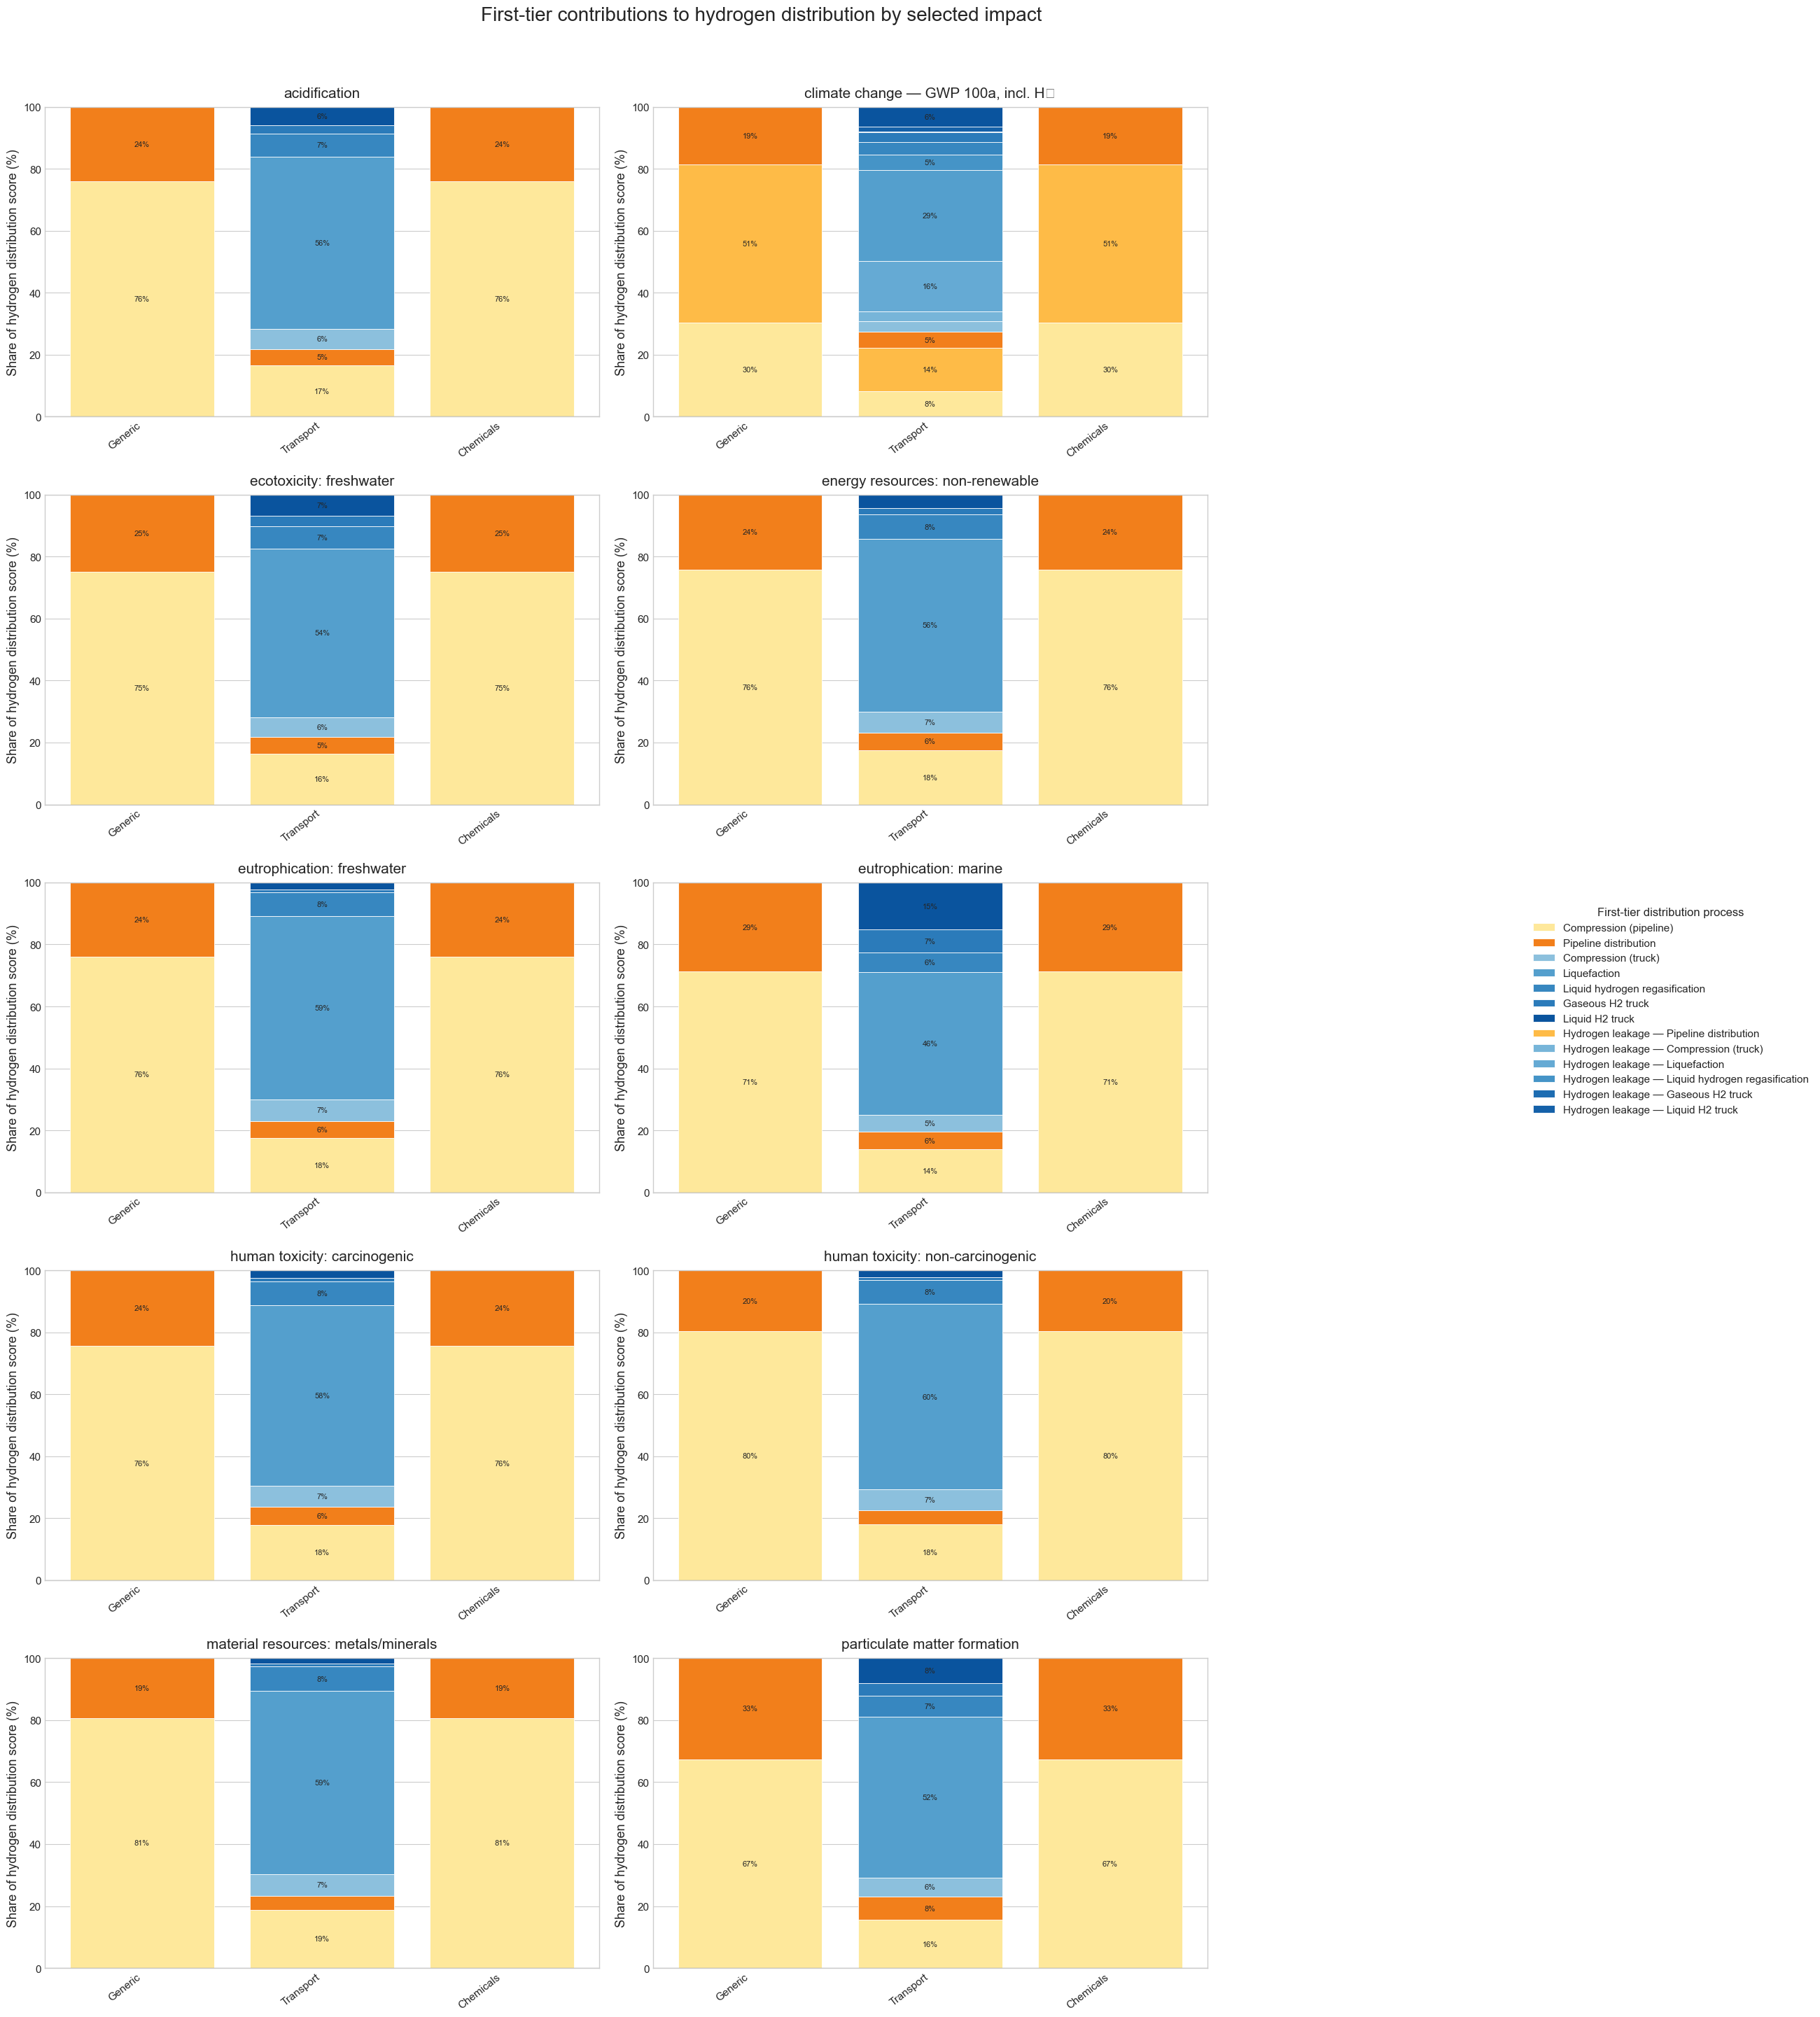

In [17]:
# First-tier decomposition of the aggregated hydrogen-distribution contribution.
distribution_keys = ["market", "method", "impact category", "unit"]
hotspot_distribution_first_tier_df = (
    hotspot_distribution_df.groupby(
        distribution_keys + ["substage", "process", "contribution type"],
        as_index=False,
        dropna=False,
    )["score"].sum()
    .rename(columns={"score": "absolute contribution"})
)
hotspot_distribution_totals_df = (
    hotspot_layer1_df.loc[
        hotspot_layer1_df["layer 1 group"].eq("Hydrogen distribution")
    ]
    .groupby(distribution_keys, as_index=False, dropna=False)["score"].sum()
    .rename(columns={"score": "hydrogen distribution score"})
)
hotspot_distribution_first_tier_df = hotspot_distribution_first_tier_df.merge(
    hotspot_distribution_totals_df,
    on=distribution_keys,
    validate="many_to_one",
)
hotspot_distribution_first_tier_df["share of hydrogen distribution (%)"] = np.where(
    hotspot_distribution_first_tier_df["hydrogen distribution score"] != 0,
    100.0
    * hotspot_distribution_first_tier_df["absolute contribution"]
    / hotspot_distribution_first_tier_df["hydrogen distribution score"],
    np.nan,
)

# Confirm that the first-tier processes reconstruct the Layer-1 distribution score.
hotspot_distribution_reconciliation_df = (
    hotspot_distribution_first_tier_df.groupby(
        distribution_keys, as_index=False, dropna=False
    )["absolute contribution"].sum()
    .rename(columns={
        "absolute contribution": "first-tier reconstructed score"
    })
    .merge(
        hotspot_distribution_totals_df,
        on=distribution_keys,
        validate="one_to_one",
    )
)
hotspot_distribution_reconciliation_df["difference"] = (
    hotspot_distribution_reconciliation_df["first-tier reconstructed score"]
    - hotspot_distribution_reconciliation_df["hydrogen distribution score"]
)
distribution_tolerance = 1e-5 * np.maximum(
    1.0,
    hotspot_distribution_reconciliation_df["hydrogen distribution score"].abs(),
)
if not (
    hotspot_distribution_reconciliation_df["difference"].abs()
    <= distribution_tolerance
).all():
    raise AssertionError(
        "First-tier processes do not reconstruct one or more hydrogen-distribution scores."
    )

hotspot_distribution_first_tier_df["impact category"] = pd.Categorical(
    hotspot_distribution_first_tier_df["impact category"],
    categories=HOTSPOT_IMPACT_CATEGORY_ORDER,
    ordered=True,
)
hotspot_distribution_first_tier_df = hotspot_distribution_first_tier_df.sort_values(
    ["impact category", "market", "substage", "process"]
).reset_index(drop=True)

display(hotspot_distribution_first_tier_df)
display(hotspot_distribution_reconciliation_df)

distribution_process_order = (
    hotspot_distribution_first_tier_df["process"].drop_duplicates().tolist()
)
distribution_process_colors = stage_analysis.distribution_process_color_map(
    distribution_process_order
)
ncols = 2
nrows = math.ceil(len(HOTSPOT_IMPACT_CATEGORY_ORDER) / ncols)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(22, 5.8 * nrows), squeeze=False
)
for ax, category in zip(axes.ravel(), HOTSPOT_IMPACT_CATEGORY_ORDER):
    subset = hotspot_distribution_first_tier_df.loc[
        hotspot_distribution_first_tier_df["impact category"] == category
    ]
    x = np.arange(len(market_order))
    positive_bottom = np.zeros(len(market_order))
    negative_bottom = np.zeros(len(market_order))

    for process in distribution_process_order:
        values = (
            subset.loc[subset["process"] == process]
            .groupby("market")["share of hydrogen distribution (%)"]
            .sum()
            .reindex(market_order, fill_value=0.0)
            .fillna(0.0)
            .to_numpy(dtype=float)
        )
        if not np.any(values):
            continue
        bottom = np.where(values >= 0, positive_bottom, negative_bottom)
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            color=distribution_process_colors[process],
            edgecolor="white",
            linewidth=0.6,
            label=process,
        )
        for bar, value, start in zip(bars, values, bottom):
            if abs(value) >= 5.0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    start + value / 2,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )
        positive_bottom += np.where(values >= 0, values, 0.0)
        negative_bottom += np.where(values < 0, values, 0.0)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(100, color="#666666", linewidth=0.7, linestyle=":")
    ax.set_title(category, fontsize=15, pad=10)
    ax.set_ylabel("Share of hydrogen distribution score (%)")
    ax.set_xticks(x, market_order, rotation=38, ha="right")

for ax in axes.ravel()[len(HOTSPOT_IMPACT_CATEGORY_ORDER):]:
    ax.set_visible(False)

legend_handles = {}
for ax in axes.ravel():
    for handle, label in zip(*ax.get_legend_handles_labels()):
        legend_handles.setdefault(label, handle)
fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    title="First-tier distribution process",
    bbox_to_anchor=(0.995, 0.5),
    loc="center left",
    frameon=False,
)
fig.suptitle(
    "First-tier contributions to hydrogen distribution by selected impact",
    fontsize=20,
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 0.80, 0.98))
plt.show()

## 9. Selected-impact spider diagram relative to Generic (RER)

This spider diagram uses exactly the impact categories defined by `HOTSPOT_IMPACT_CATEGORY_ORDER`. For each category, every market score is divided by the score of `Generic (RER)`. The generic market is therefore exactly **1** on every axis; a sector value of 2 means twice the generic impact, while 0.5 means half the generic impact. This is a ratio comparison, not EF normalization or weighting.

market,Generic,Transport,Chemicals
impact category,,,
acidification,1.0,1.062962,0.990242
"climate change — GWP 100a, incl. H₂",1.0,1.064564,0.984403
ecotoxicity: freshwater,1.0,1.069756,0.989256
energy resources: non-renewable,1.0,1.052558,0.990941
eutrophication: freshwater,1.0,1.070569,0.987905
eutrophication: marine,1.0,1.072559,0.990711
human toxicity: carcinogenic,1.0,1.073459,0.986829
human toxicity: non-carcinogenic,1.0,1.076946,0.987336
material resources: metals/minerals,1.0,1.073708,0.987160


c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


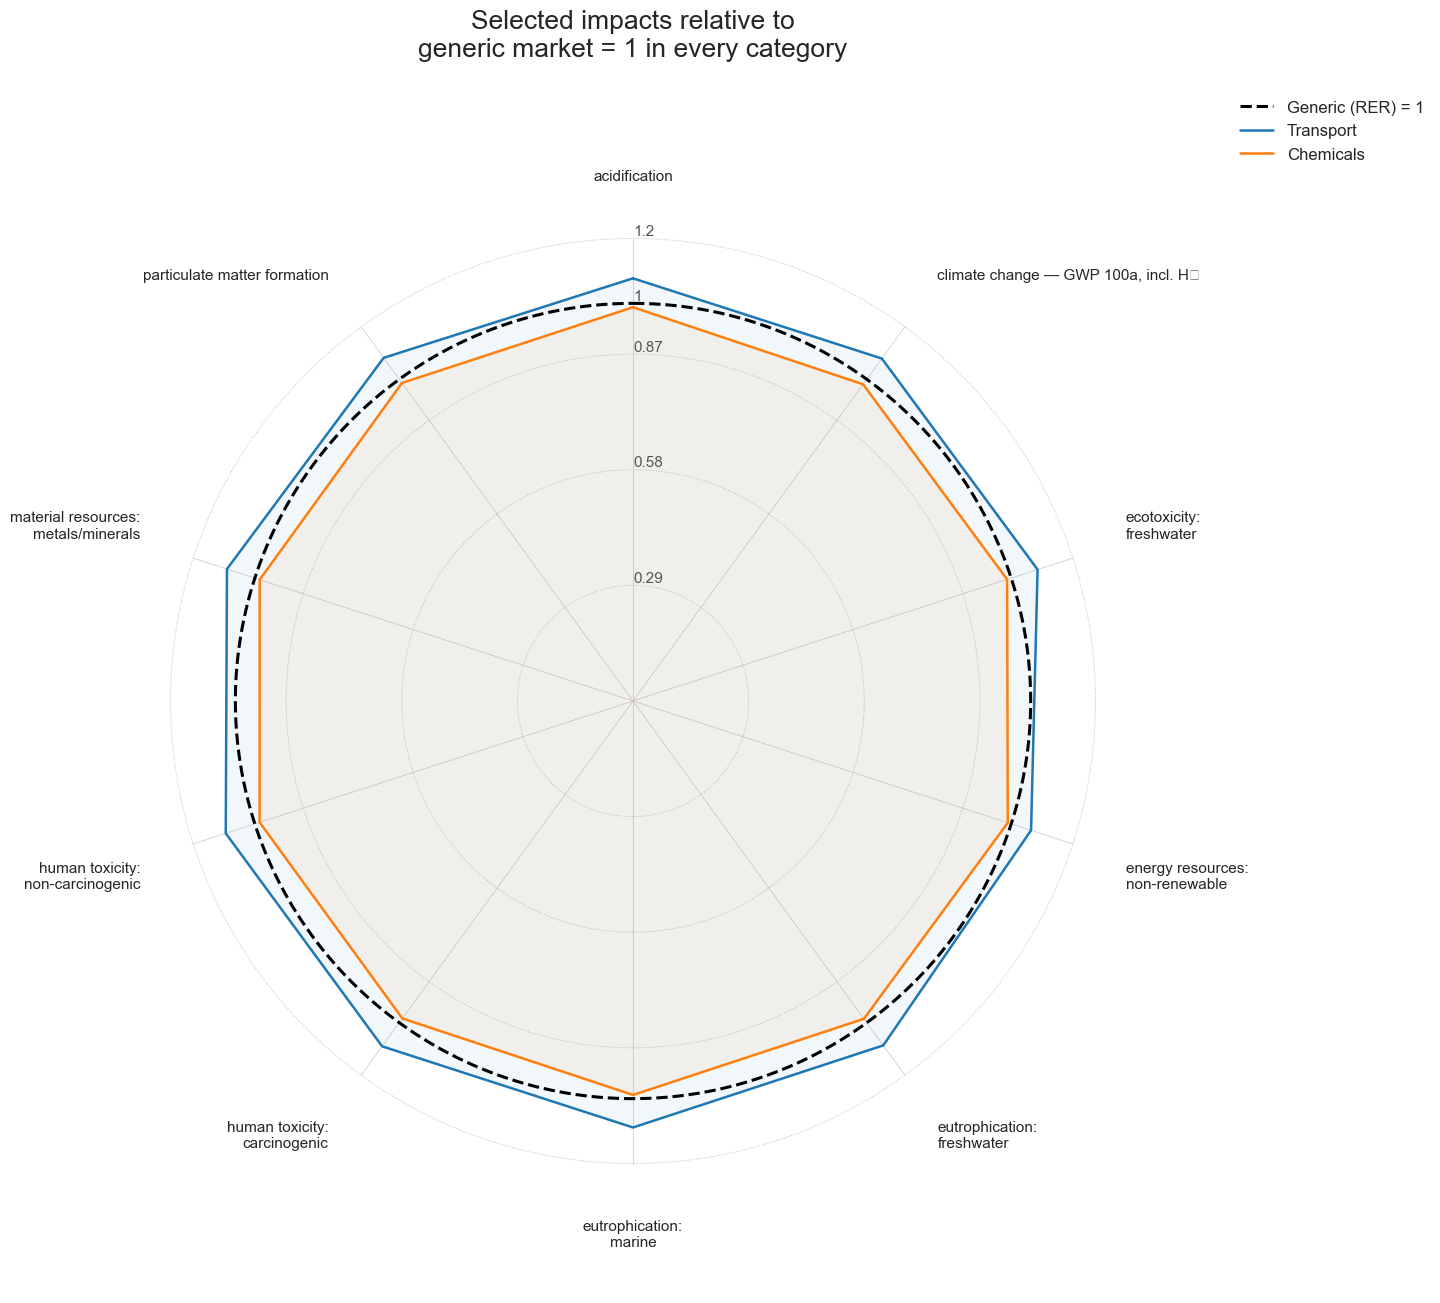

In [18]:
selected_impact_scores = scores_df[
    scores_df["impact category"].isin(HOTSPOT_IMPACT_CATEGORY_ORDER)
].copy()
selected_impact_score_matrix = (
    selected_impact_scores.pivot(
        index="impact category", columns="market", values="score per kg H2"
    )
    .reindex(index=HOTSPOT_IMPACT_CATEGORY_ORDER, columns=market_order)
)

generic_scores = selected_impact_score_matrix["Generic"]
zero_baselines = generic_scores.index[generic_scores == 0].tolist()
if zero_baselines:
    raise ZeroDivisionError(
        "Generic has a zero selected-impact score, so a relative ratio cannot be calculated for: "
        + ", ".join(zero_baselines)
    )

spider_ratio_df = selected_impact_score_matrix.div(generic_scores, axis=0)
spider_ratio_df["Generic"] = 1.0  # exact reference circle
if not np.isfinite(spider_ratio_df.to_numpy(dtype=float)).all():
    raise AssertionError("The selected-impact spider ratios contain non-finite values.")
if (spider_ratio_df.to_numpy(dtype=float) < 0).any():
    warnings.warn("Negative selected-impact ratios are present and require care on a polar chart.")

display(spider_ratio_df.rename_axis(columns="market"))

angles = np.linspace(0, 2 * np.pi, len(HOTSPOT_IMPACT_CATEGORY_ORDER), endpoint=False)
axis_labels = [category.replace(": ", ":\n") for category in HOTSPOT_IMPACT_CATEGORY_ORDER]

# Draw the spider in Cartesian coordinates. This is equivalent to a polar radar plot,
# while remaining compatible with Matplotlib installations whose polar projection is unavailable.
x_directions = np.sin(angles)  # start at the top and proceed clockwise
y_directions = np.cos(angles)
radial_max = max(1.1, float(spider_ratio_df[sector_order].max().max()) * 1.08)

fig, ax = plt.subplots(figsize=(16, 16))
grid_levels = sorted(set(np.linspace(0, radial_max, 5).tolist() + [1.0]))
circle_angles = np.linspace(0, 2 * np.pi, 361)
for level in grid_levels:
    if level == 0:
        continue
    ax.plot(
        level * np.sin(circle_angles), level * np.cos(circle_angles),
        color="black" if np.isclose(level, 1.0) else "#bdbdbd",
        linewidth=2.2 if np.isclose(level, 1.0) else 0.7,
        linestyle="--" if np.isclose(level, 1.0) else ":",
        label="Generic (RER) = 1" if np.isclose(level, 1.0) else None,
        zorder=5 if np.isclose(level, 1.0) else 1,
    )
    ax.text(0, level, f"{level:.2g}", fontsize=11, color="#555555", ha="left", va="bottom")

label_radius = radial_max * 1.12
for x_direction, y_direction, label in zip(x_directions, y_directions, axis_labels):
    ax.plot([0, radial_max * x_direction], [0, radial_max * y_direction],
            color="#d0d0d0", linewidth=0.6, zorder=0)
    horizontal_alignment = "center" if abs(x_direction) < 0.15 else ("left" if x_direction > 0 else "right")
    vertical_alignment = "center" if abs(y_direction) < 0.15 else ("bottom" if y_direction > 0 else "top")
    ax.text(
        label_radius * x_direction, label_radius * y_direction, label,
        fontsize=11, ha=horizontal_alignment, va=vertical_alignment,
    )

sector_colors = plt.get_cmap("tab10")(np.arange(len(sector_order)))
for color, market_label in zip(sector_colors, sector_order):
    values = spider_ratio_df[market_label].to_numpy(dtype=float)
    x_values = values * x_directions
    y_values = values * y_directions
    closed_x = np.r_[x_values, x_values[0]]
    closed_y = np.r_[y_values, y_values[0]]
    ax.plot(closed_x, closed_y, linewidth=1.8, color=color, label=market_label, zorder=3)
    ax.fill(closed_x, closed_y, color=color, alpha=0.06, zorder=2)

plot_limit = radial_max * 1.28
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.set_title(
    "Selected impacts relative to\ngeneric market = 1 in every category",
    fontsize=19, pad=38,
)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.02), frameon=False, fontsize=12)
fig.subplots_adjust(left=0.08, right=0.82, top=0.90, bottom=0.08)
plt.show()

## 10. Life-cycle-stage contribution analysis

The hierarchical contribution analysis is calculated only for the hydrogen-inclusive `PREMISE_GWP_METHOD`; all other methods remain available in the comparative LCIA results. This analysis uses functional stages instead of graph distance.

The **Process group CA - hydrogen production technologies and aggregated distribution** chart shows each hydrogen production technology in the market and aggregated hydrogen distribution as relative shares of the market total. **Layer 2** reports absolute premise-GWP contributions in the method unit per kg H2: it decomposes every production technology into its main direct-input groups. The **Process group CA - transport, conversion, and reconversion by market** chart combines all distribution processes in one plot. Direct hydrogen and ammonia emissions from distribution are reported as `Hydrogen leakage` and `Ammonia leakage`; production emissions remain assigned to their production technology. All branches retain their complete upstream LCIA burdens, and both layers are checked against the total market score.

In [19]:

import importlib
import sys

# Calculation helpers remain separate; their mappings come from LCIA_mapping_h2.py.
stage_module_dir = ANALYSIS_DIR / "notebooks"
if str(stage_module_dir) not in sys.path:
    sys.path.insert(0, str(stage_module_dir))
import lcia_stage_analysis as stage_analysis
importlib.reload(stage_analysis)

stage_results = stage_analysis.analyze_hydrogen_life_cycle_stages(
    selected=selected,
    market_order=market_order,
    method=PREMISE_GWP_METHOD,
    functional_unit=FUNCTIONAL_UNIT_KG,
    scores_df=scores_df,
    impact_category=impact_category_label(PREMISE_GWP_METHOD),
    unit=method_units[PREMISE_GWP_METHOD],
)

stage_layer1_df = stage_results["layer1"]
production_inputs_detailed_df = stage_results["production inputs detailed"]
production_input_groups_df = stage_results["production input groups"]
distribution_processes_df = stage_results["distribution processes"]
stage_classification_audit_df = stage_results["classification audit"]
stage_reconciliation_df = stage_results["reconciliation"]

display(stage_classification_audit_df)
display(stage_reconciliation_df)
display(stage_layer1_df.head(20))
display(production_input_groups_df.head(20))
display(distribution_processes_df.head(20))

,market,market location,provider,provider product,provider unit,provider location,provider key,demand amount,stage,substage,component,classification rule
0,Generic,RER,"hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity","hydrogen, gaseous, 30 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5a9112f9fa304a17be3ea3ea271ed542)",6.560934e-01,Production,Production technology,PEM electrolysis,hydrogen production activity
1,Generic,RER,"hydrogen production, gaseous, 25 bar, from gasification of woody biomass in entrained flow gasifier, at gasification plant","hydrogen, gaseous, 25 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, ada97cc4c55447b4a06870ba98faccd8)",5.647860e-06,Production,Production technology,Biomass gasification,hydrogen production activity
2,Generic,RER,"hydrogen production, gaseous, 25 bar, from gasification of woody biomass in entrained flow gasifier, with CCS, at gasification plant","hydrogen, gaseous, 25 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, eefacb3d4bbf403c9ffce23acf026b31)",1.692493e-01,Production,Production technology,Biomass gasification with CCS,hydrogen production activity
3,Generic,RER,"hydrogen production, coal gasification, with CCS","hydrogen, gaseous, low pressure",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 9ee4125b33314d008da674366761d42b)",2.477131e-06,Production,Production technology,Coal gasification with CCS,hydrogen production activity
4,Generic,RER,"hydrogen production, steam methane reforming","hydrogen, gaseous, low pressure",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, c31630e2036645d58836a23fd4b80272)",1.148944e-01,Production,Production technology,Steam methane reforming,hydrogen production activity
5,Generic,RER,"hydrogen production, steam methane reforming, with CCS","hydrogen, gaseous, low pressure",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 3f462590a6a249639de4690dd93e9375)",5.975475e-02,Production,Production technology,Steam methane reforming with CCS,hydrogen production activity
6,Generic,RER,"hydrogen supply, distributed by pipeline","hydrogen, gaseous, from pipeline",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5d705a5d008347a38c05cb6fe9fd1d1d)",1.000000e+00,Distribution,Transport,Pipeline distribution,exact transport activity
7,Generic,RER,compressor assembly for transmission hydrogen pipeline,"compressor, for hydrogen transmission",unit,RER,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, e5d1ca12eacd4a32bf13efe85a63328a)",3.227031e-11,Distribution,Conversion,Compression (pipeline),pipeline compression input
8,Generic,RER,"market group for electricity, low voltage","electricity, low voltage",kilowatt hour,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 2f9b709b67264930a3d371cb313e295c)",1.816554e+00,Distribution,Conversion,Compression (pipeline),pipeline compression input
9,Transport,EUR,"hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity","hydrogen, gaseous, 30 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5a9112f9fa304a17be3ea3ea271ed542)",6.560934e-01,Production,Production technology,PEM electrolysis,hydrogen production activity


,market,method,impact category,unit,total score,Layer 1 reconstructed score,Layer 1 difference,Layer 2 reconstructed score,Layer 2 difference
0,Generic,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq,1.911454,1.911454,-3.843367e-09,1.911454,-2.999055e-08
1,Transport,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq,2.034865,2.034865,-4.304522e-09,2.034865,-3.045171e-08
2,Chemicals,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq,1.881642,1.881642,-5.620337e-09,1.881642,-3.176752e-08


,market,layer 1 group,component,contribution type,score,share of market (%),physical amount,physical unit,method,impact category,unit
0,Generic,Production technology,PEM electrolysis,Technology excluding leakage,0.838748,43.880107,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
1,Generic,Production technology,Biomass gasification,Technology excluding leakage,0.000001,0.000072,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
2,Generic,Production technology,Biomass gasification with CCS,Technology excluding leakage,0.062930,3.292263,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
3,Generic,Production technology,Coal gasification with CCS,Technology excluding leakage,0.000012,0.000641,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
4,Generic,Production technology,Steam methane reforming,Technology excluding leakage,0.780401,40.827616,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
5,Generic,Production technology,Steam methane reforming with CCS,Technology excluding leakage,0.080298,4.200872,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
6,Generic,Hydrogen distribution,Hydrogen distribution,Distribution excluding leakage,0.073006,3.819373,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
7,Generic,Hydrogen distribution,Hydrogen leakage — distribution,Hydrogen leakage,0.076058,3.979056,0.006914,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
8,Transport,Production technology,PEM electrolysis,Technology excluding leakage,0.838748,41.218859,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
9,Transport,Production technology,Biomass gasification,Technology excluding leakage,0.000001,0.000067,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq


,market,technology,input group,contribution type,score,score per kg H2,share of market (%),method,impact category,unit
0,Chemicals,Biomass gasification,Biomass feedstock,Upstream input,1.314589e-06,1.881642,6.986391e-05,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
1,Chemicals,Biomass gasification,Infrastructure,Upstream input,1.988612e-08,1.881642,1.056849e-06,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
2,Chemicals,Biomass gasification,Other direct emissions,Other direct emissions,0.000000e+00,1.881642,0.000000e+00,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
3,Chemicals,Biomass gasification,Water,Upstream input,3.390209e-08,1.881642,1.801729e-06,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
4,Chemicals,Biomass gasification with CCS,Biomass feedstock,Upstream input,3.939425e-02,1.881642,2.093611e+00,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
5,Chemicals,Biomass gasification with CCS,CO2 capture and storage,Upstream input,2.192318e-02,1.881642,1.165109e+00,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
6,Chemicals,Biomass gasification with CCS,Infrastructure,Upstream input,5.959270e-04,1.881642,3.167059e-02,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
7,Chemicals,Biomass gasification with CCS,Other direct emissions,Other direct emissions,0.000000e+00,1.881642,0.000000e+00,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
8,Chemicals,Biomass gasification with CCS,Water,Upstream input,1.016752e-03,1.881642,5.403537e-02,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
9,Chemicals,Coal gasification with CCS,CO2 capture and storage,Upstream input,2.504938e-07,1.881642,1.331252e-05,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq


,market,substage,process,process key,contribution type,score,share of market (%),physical amount,physical unit,method,impact category,unit
0,Generic,Transport,Pipeline distribution,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5d705a5d008347a38c05cb6fe9fd1d1d)",Process excluding leakage,0.027816,1.455207,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
1,Generic,Conversion,Compression (pipeline),"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, e5d1ca12eacd4a32bf13efe85a63328a)",Process excluding leakage,0.000011,0.000552,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
2,Generic,Conversion,Compression (pipeline),"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 2f9b709b67264930a3d371cb313e295c)",Process excluding leakage,0.045179,2.363614,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
3,Generic,Transport,Hydrogen leakage — Pipeline distribution,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5d705a5d008347a38c05cb6fe9fd1d1d)",Hydrogen leakage,0.076058,3.979056,0.006914,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
4,Transport,Transport,Gaseous H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 9ffbe1ee6c6a452182d232f0df34758d)",Process excluding leakage,0.008418,0.413682,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
5,Transport,Transport,Hydrogen leakage — Gaseous H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 9ffbe1ee6c6a452182d232f0df34758d)",Hydrogen leakage,0.000687,0.033786,0.000062,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
6,Transport,Transport,Liquid H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 6074875a95484b3e9e040d9fa715819f)",Process excluding leakage,0.017373,0.853783,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
7,Transport,Transport,Hydrogen leakage — Liquid H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 6074875a95484b3e9e040d9fa715819f)",Hydrogen leakage,0.004469,0.219609,0.000406,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
8,Transport,Transport,Pipeline distribution,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 5d705a5d008347a38c05cb6fe9fd1d1d)",Process excluding leakage,0.013908,0.683476,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq
9,Transport,Conversion,Compression (pipeline),"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, e5d1ca12eacd4a32bf13efe85a63328a)",Process excluding leakage,0.000005,0.000259,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq


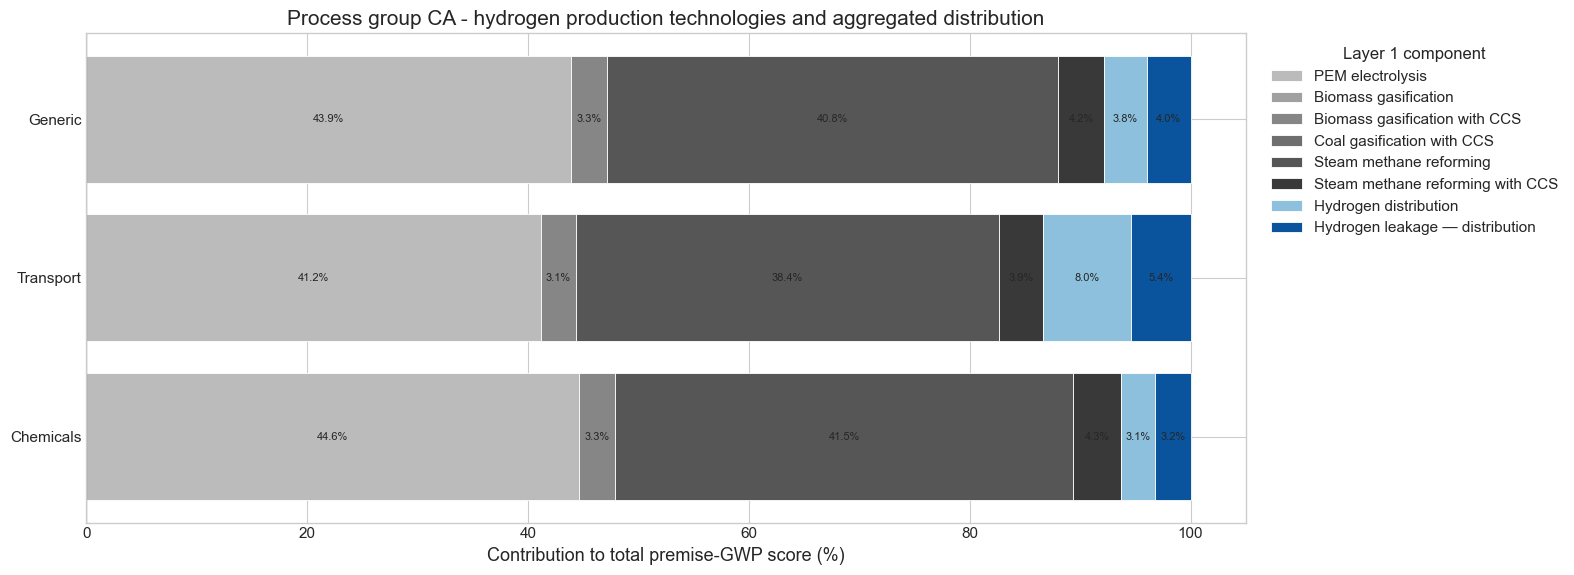

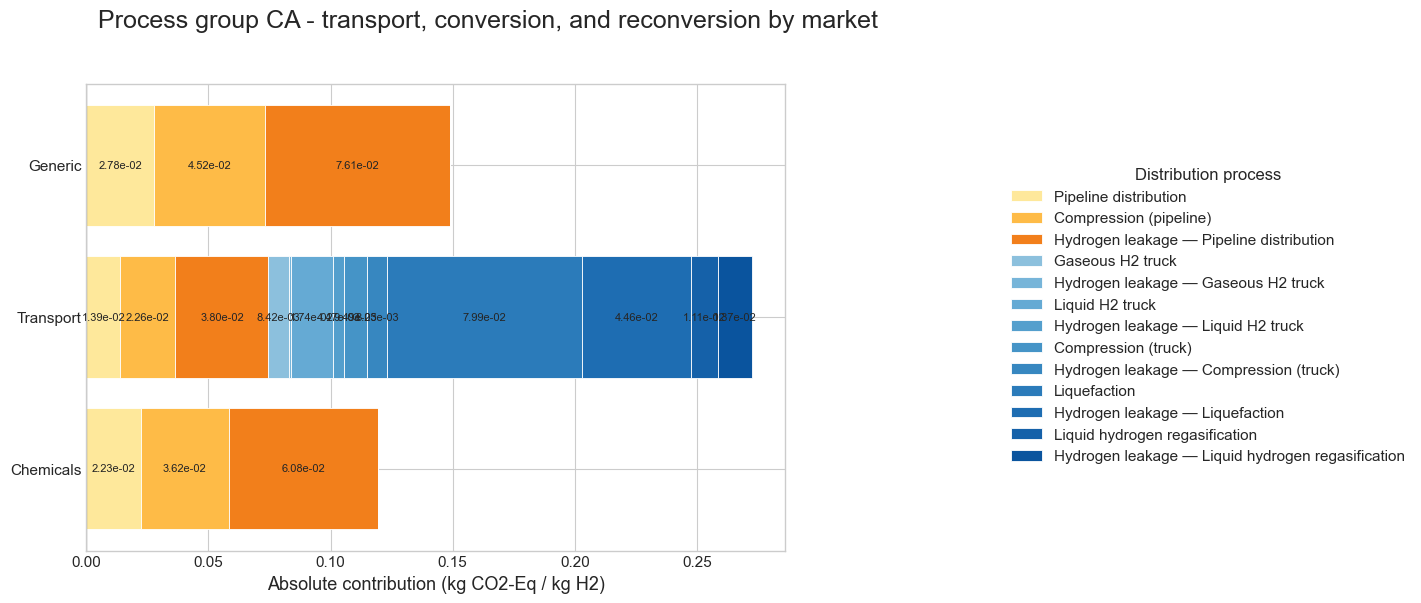

In [20]:

stage_analysis.plot_stage_layer1(stage_layer1_df, market_order)
# stage_analysis.plot_production_layer2(production_input_groups_df, market_order)
stage_analysis.plot_distribution_layer2(distribution_processes_df, market_order)

## 11. Export numerical results

The exports include the selection audit, all canonically selected LCIA scores, comparisons with the generic RER market, the EF 3.1 spider ratios, selected-impact hotspot process-group shares and reconciliation, premise-GWP full-system process contributions, and the Layer 1, Layer 2, classification-audit, and reconciliation tables.

In [21]:
output_dir = Path.cwd() if Path.cwd().name == "dev" else Path.cwd() / "dev"
output_dir.mkdir(parents=True, exist_ok=True)
exports = {
    "selection": (selection_df, output_dir / "hydrogen_markets_europe_selection.csv"),
    "scores": (scores_df, output_dir / "hydrogen_markets_europe_lcia_scores_per_kg.csv"),
    "RER comparison": (comparison_rer_df, output_dir / "hydrogen_markets_europe_vs_generic_RER.csv"),
    "EF 3.1 spider ratios": (spider_ratio_df, output_dir / "hydrogen_markets_europe_ef31_ratios_vs_generic_RER.csv"),
    "Hotspot process groups": (hotspot_process_group_df, output_dir / "hydrogen_markets_europe_hotspot_process_groups.csv"),
    "Hotspot reconciliation": (hotspot_reconciliation_df, output_dir / "hydrogen_markets_europe_hotspot_reconciliation.csv"),
    "contributions": (contributions_df, output_dir / "hydrogen_markets_europe_lcia_process_contributions.csv"),
    "Stage Layer 1": (stage_layer1_df, output_dir / "hydrogen_markets_europe_stage_layer1.csv"),
    "Production inputs detailed": (production_inputs_detailed_df, output_dir / "hydrogen_markets_europe_production_inputs_detailed.csv"),
    "Production input groups": (production_input_groups_df, output_dir / "hydrogen_markets_europe_production_input_groups.csv"),
    "Distribution processes": (distribution_processes_df, output_dir / "hydrogen_markets_europe_distribution_processes.csv"),
    "Stage classification audit": (stage_classification_audit_df, output_dir / "hydrogen_markets_europe_stage_classification_audit.csv"),
    "Stage reconciliation": (stage_reconciliation_df, output_dir / "hydrogen_markets_europe_stage_reconciliation.csv"),
}
#for label, (dataframe, path) in exports.items():
    #dataframe.to_csv(path, index=False)
    #print(f"{label:28s}: {path.resolve()}")

#display(scores_df.sort_values(["impact category", "market"]))

## Interpretation checklist

1. Confirm the selection table before interpreting results, especially the `RER` generic versus `EUR` sector geography.
2. Use `Generic (RER)` as the sole baseline for every sector comparison.
3. Compare scores only within the same impact category and unit; do not add unnormalized midpoint results.
4. Treat missing sector markets as scenario results: they indicate no positive modeled hydrogen demand for that sector/region combination.
5. Inspect negative contributions and shares above 100%; these represent credits or offsetting burdens and are not automatically errors.
6. Use the premise GWP100 result to capture hydrogen emissions to air; the standard EF 3.1 climate-change category is retained separately.
7. Interpret every selected method in its reported unit; do not compare numerical values across unlike impact categories.
8. Read the EF 3.1 spider diagram as ratios: 1 equals the Generic (RER) score, values above 1 are higher, and values below 1 are lower.
9. Use the relative Layer 1 shares to compare production technologies with aggregated hydrogen distribution. Use the absolute Layer 2 scores to inspect production inputs and the transport, conversion, and reconversion processes; verify both against the reconciliation table.

Selected 1 regional steel hydrogen markets; excluded WORLD.


,region,name,reference product,unit,database key
0,JPN,"market for hydrogen, gaseous, low pressure, for steel","hydrogen, gaseous, low pressure",kilogram,"(ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full, 4819ccbc63414ab0af81a4cfaf36222d)"


Finished JPN


,market,method,impact category,unit,total score,Layer 1 reconstructed score,Layer 1 difference,Layer 2 reconstructed score,Layer 2 difference
0,JPN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H₂",kg CO2-Eq,2.198211,2.198211,-9.563075e-09,2.198211,-4.751292e-08


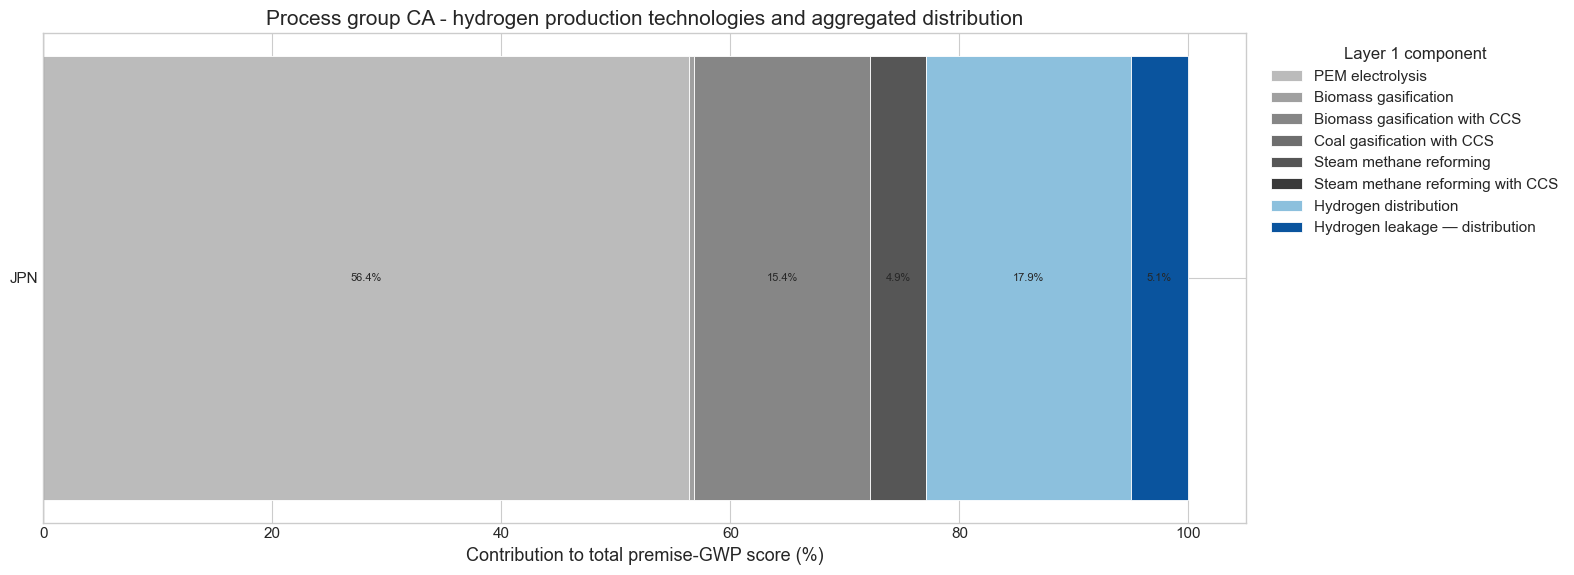

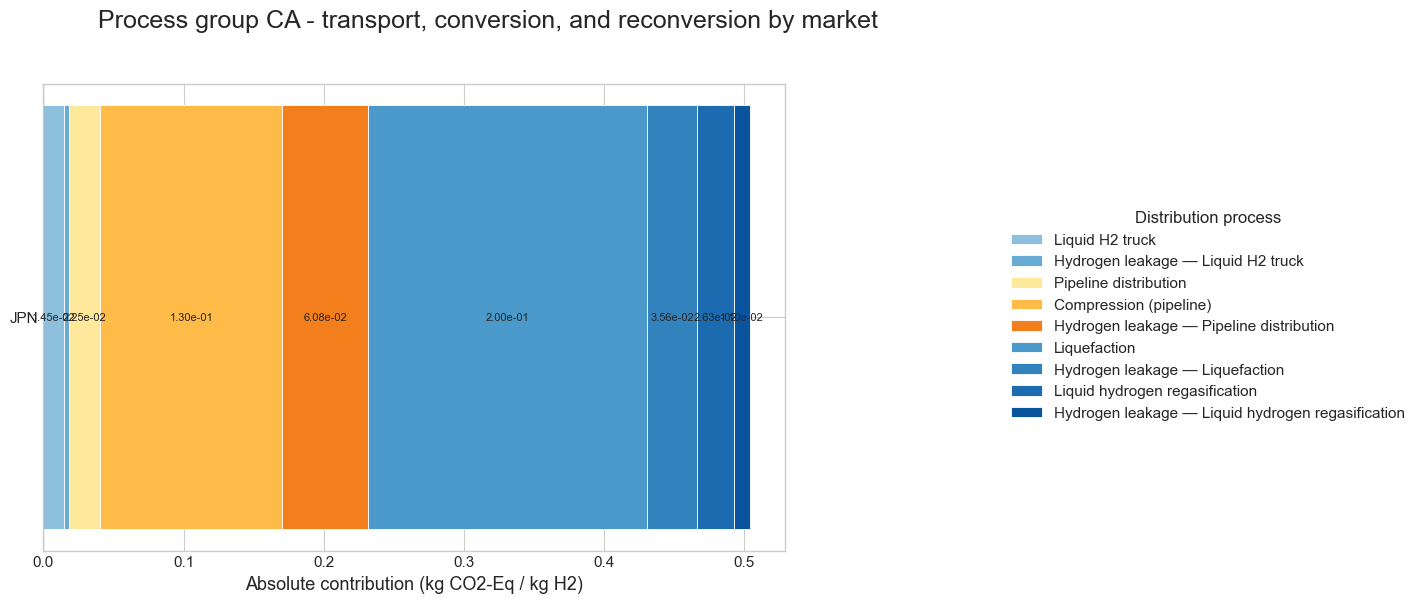

In [22]:
# Compare the exact steel-specific low-pressure gaseous hydrogen market across all
# available regional locations, excluding the aggregate WORLD market.
STEEL_MARKET_NAME = "market for hydrogen, gaseous, low pressure, for steel"
EXCLUDED_STEEL_LOCATION = "WORLD"

steel_region_activities = sorted(
    [
        activity for activity in database
        if activity.get("name") == STEEL_MARKET_NAME
        and activity.get("reference product") == REFERENCE_PRODUCT
        and activity.get("unit") == UNIT
        and str(activity.get("location", "")).upper() != EXCLUDED_STEEL_LOCATION
    ],
    key=lambda activity: (activity.get("location", ""), str(activity.key)),
)
if not steel_region_activities:
    raise LookupError(
        f"No exact {STEEL_MARKET_NAME!r} activities outside "
        f"{EXCLUDED_STEEL_LOCATION!r} were found in {DATABASE!r}."
    )

location_counts = pd.Series(
    [activity.get("location") for activity in steel_region_activities]
).value_counts()
duplicate_locations = location_counts[location_counts > 1].index.tolist()
if duplicate_locations:
    raise LookupError(
        "Expected one exact steel hydrogen market per region; duplicate locations: "
        + ", ".join(duplicate_locations)
    )

steel_region_selected = {
    activity.get("location"): activity for activity in steel_region_activities
}
steel_region_order = list(steel_region_selected)
steel_region_selection_df = pd.DataFrame([
    {
        "region": region,
        "name": activity.get("name"),
        "reference product": activity.get("reference product"),
        "unit": activity.get("unit"),
        "database key": activity.key,
    }
    for region, activity in steel_region_selected.items()
])
print(
    f"Selected {len(steel_region_selected)} regional steel hydrogen markets; "
    f"excluded {EXCLUDED_STEEL_LOCATION}."
)
display(steel_region_selection_df)

# Calculate the premise GWP score required by the process-group analysis.
steel_region_score_records = []
for region, activity in steel_region_selected.items():
    lca = bc.LCA({activity: FUNCTIONAL_UNIT_KG}, PREMISE_GWP_METHOD)
    lca.lci()
    lca.lcia()
    steel_region_score_records.append({
        "market": region,
        "market name": activity.get("name"),
        "location": activity.get("location"),
        "impact category": impact_category_label(PREMISE_GWP_METHOD),
        "indicator": PREMISE_GWP_METHOD[-1],
        "method": PREMISE_GWP_METHOD,
        "unit": method_units[PREMISE_GWP_METHOD],
        "score per kg H2": float(lca.score),
    })
    print(f"Finished {region}")

steel_region_scores_df = pd.DataFrame(steel_region_score_records)
steel_region_stage_results = stage_analysis.analyze_hydrogen_life_cycle_stages(
    selected=steel_region_selected,
    market_order=steel_region_order,
    method=PREMISE_GWP_METHOD,
    functional_unit=FUNCTIONAL_UNIT_KG,
    scores_df=steel_region_scores_df,
    impact_category=impact_category_label(PREMISE_GWP_METHOD),
    unit=method_units[PREMISE_GWP_METHOD],
    reconciliation_rtol=1e-5,
)

steel_region_layer1_df = steel_region_stage_results["layer1"]
steel_region_distribution_df = steel_region_stage_results["distribution processes"]
steel_region_reconciliation_df = steel_region_stage_results["reconciliation"]
display(steel_region_reconciliation_df)

# First: production technologies versus aggregated distribution (relative shares).
stage_analysis.plot_stage_layer1(steel_region_layer1_df, steel_region_order)

# Second: distribution only, split into transport, conversion, and reconversion processes.
stage_analysis.plot_distribution_layer2(
    steel_region_distribution_df,
    steel_region_order,
)

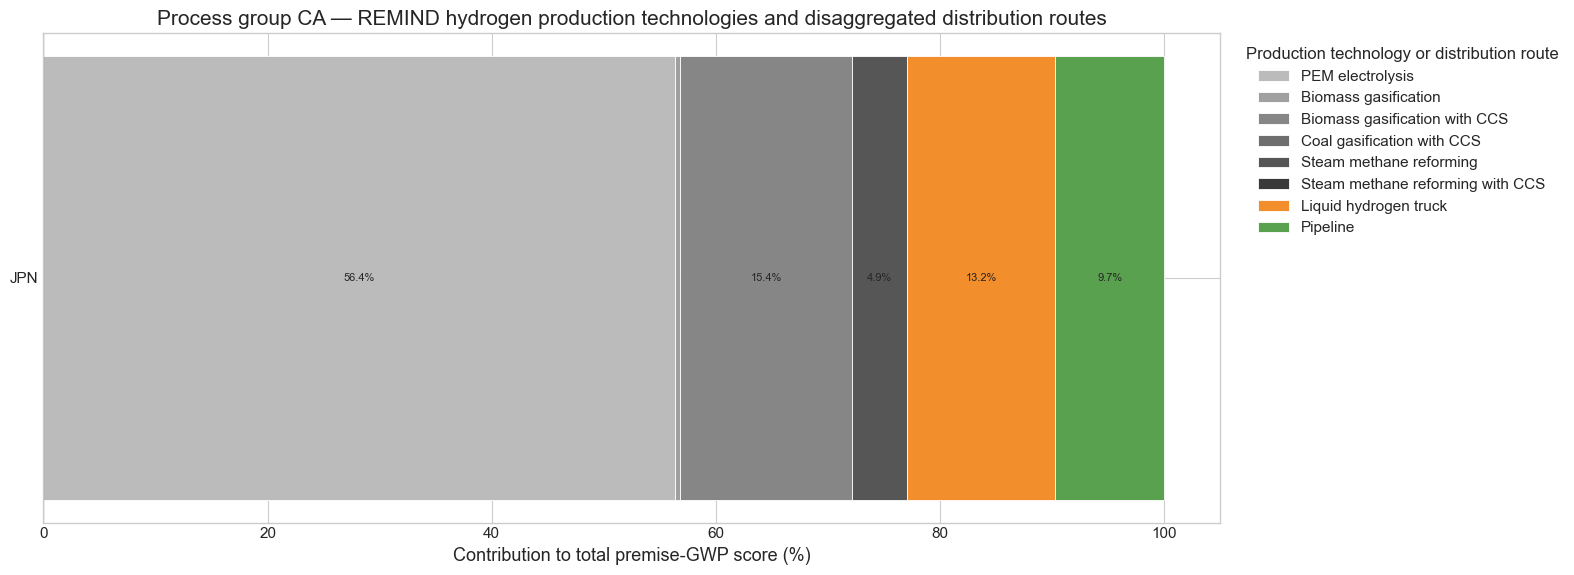

,market,layer 1 group,component,score,share of market (%)
0,JPN,Production technology,PEM electrolysis,1.239621,56.392252
1,JPN,Production technology,Biomass gasification,0.009599,0.436651
2,JPN,Production technology,Biomass gasification with CCS,0.337799,15.366996
3,JPN,Production technology,Coal gasification with CCS,0.000077,0.003520
4,JPN,Production technology,Steam methane reforming,0.107287,4.880642
5,JPN,Production technology,Steam methane reforming with CCS,0.000052,0.002369
6,JPN,Distribution route,Liquid hydrogen truck,0.290530,13.216635
7,JPN,Distribution route,Pipeline,0.213247,9.700935


In [23]:
# Combined REMIND process-group CA: retain individual production technologies and
# replace aggregated distribution with the route-level categories used above.
# Route names and colors are canonical; this cell only applies them.
REMIND_DISTRIBUTION_ROUTES = h2map.ROUTE_COLORS

def distribution_route(process):
    """Map each Layer-2 distribution process to a visible route."""
    return h2map.distribution_family(process)

# Keep only the technology rows from Layer 1; the aggregated distribution rows
# are replaced below by route totals calculated from the detailed Layer-2 table.
remind_production_df = steel_region_layer1_df.loc[
    steel_region_layer1_df["layer 1 group"].eq("Production technology")
].copy()
remind_distribution_routes_df = steel_region_distribution_df.copy()
remind_distribution_routes_df["component"] = (
    remind_distribution_routes_df["process"].map(distribution_route)
)
remind_distribution_routes_df = (
    remind_distribution_routes_df.groupby(["market", "component"], as_index=False)["score"]
    .sum()
)
remind_distribution_routes_df["layer 1 group"] = "Distribution route"

remind_market_totals = (
    steel_region_scores_df.set_index("market")["score per kg H2"]
)
remind_distribution_routes_df["share of market (%)"] = (
    100.0
    * remind_distribution_routes_df["score"]
    / remind_distribution_routes_df["market"].map(remind_market_totals)
)

steel_region_disaggregated_layer1_df = pd.concat(
    [
        remind_production_df[["market", "layer 1 group", "component", "score", "share of market (%)"]],
        remind_distribution_routes_df[["market", "layer 1 group", "component", "score", "share of market (%)"]],
    ],
    ignore_index=True,
)

# The disaggregated components must still reconstruct the original market LCIA score.
remind_reconstructed = (
    steel_region_disaggregated_layer1_df.groupby("market")["score"]
    .sum()
    .reindex(steel_region_order)
)
if not np.allclose(
    remind_reconstructed.to_numpy(),
    remind_market_totals.reindex(steel_region_order).to_numpy(),
    rtol=1e-5,
    atol=1e-12,
):
    raise AssertionError(
        "Production technologies plus disaggregated distribution routes "
        "do not reconstruct the REMIND steel-market scores."
    )

remind_component_colors = stage_analysis.stage_layer1_color_map(
    remind_production_df
)
remind_component_colors.update(REMIND_DISTRIBUTION_ROUTES)
fig, ax = plt.subplots(
    figsize=(16, max(6, 0.75 * len(steel_region_order) + 2))
)
stage_analysis._plot_signed_stacks(
    ax,
    steel_region_disaggregated_layer1_df,
    steel_region_order,
    "component",
    remind_component_colors,
    value_column="share of market (%)",
    xlabel="Contribution to total premise-GWP score (%)",
    label_threshold=3.0,
    value_format="{:.1f}%",
)
ax.set_title(
    "Process group CA — REMIND hydrogen production technologies and "
    "disaggregated distribution routes"
)
ax.legend(
    title="Production technology or distribution route",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
)
fig.tight_layout()
plt.show()

display(steel_region_disaggregated_layer1_df)

In [24]:
# Diagnose the high ammonia-cracking GWP contribution by scoring every direct
# technosphere input and direct characterized emission at the market demand.
# Use the canonical reporting name when selecting cracking contributions.
AMMONIA_CRACKING_COMPONENT = h2map.AMMONIA_CRACKING_COMPONENT
TOP_CRACKING_INPUTS = 10

steel_region_audit_df = steel_region_stage_results["classification audit"]
ammonia_cracking_audit_df = steel_region_audit_df.loc[
    steel_region_audit_df["component"].eq(AMMONIA_CRACKING_COMPONENT)
].copy()
if ammonia_cracking_audit_df.empty:
    raise LookupError("No ammonia-cracking branches were found in the selected steel markets.")

cracking_cf_lookup = stage_analysis._method_cf_lookup(PREMISE_GWP_METHOD)
cracking_input_records = []
cracking_total_records = []

for _, branch in ammonia_cracking_audit_df.iterrows():
    market = branch["market"]
    cracker = bd.get_activity(branch["provider key"])
    cracking_demand = float(branch["demand amount"])
    reference_output = stage_analysis._reference_output_amount(cracker)
    scale = cracking_demand / reference_output
    scorer = stage_analysis._DemandScorer(
        steel_region_selected[market], PREMISE_GWP_METHOD
    )
    cracking_total_records.append({
        "market": market,
        "cracking activity": cracker.get("name"),
        "cracking location": cracker.get("location"),
        "cracking demand": cracking_demand,
        "cracking demand unit": cracker.get("unit"),
        "cracking GWP score": scorer.score(cracker, cracking_demand),
    })

    for exchange in cracker.technosphere():
        provider = exchange.input
        input_demand = scale * float(exchange.get("amount", 0.0))
        cracking_input_records.append({
            "market": market,
            "input type": "Technosphere",
            "input process": provider.get("name"),
            "input product or flow": provider.get("reference product"),
            "input location": provider.get("location"),
            "input amount": input_demand,
            "input unit": provider.get("unit"),
            "GWP score": scorer.score(provider, input_demand),
        })

    for exchange in cracker.biosphere():
        flow = exchange.input
        flow_amount = scale * float(exchange.get("amount", 0.0))
        characterization_factor = cracking_cf_lookup.get(int(flow.id), 0.0)
        cracking_input_records.append({
            "market": market,
            "input type": "Direct biosphere",
            "input process": f"Direct emission — {flow.get('name')}",
            "input product or flow": flow.get("name"),
            "input location": "biosphere",
            "input amount": flow_amount,
            "input unit": flow.get("unit"),
            "GWP score": flow_amount * characterization_factor,
        })

ammonia_cracking_inputs_df = pd.DataFrame(cracking_input_records)
ammonia_cracking_totals_df = (
    pd.DataFrame(cracking_total_records)
    .groupby("market", as_index=False)
    .agg({
        "cracking activity": "first",
        "cracking location": "first",
        "cracking demand": "sum",
        "cracking demand unit": "first",
        "cracking GWP score": "sum",
    })
)
cracking_total_lookup = ammonia_cracking_totals_df.set_index("market")["cracking GWP score"]
market_score_lookup = steel_region_scores_df.set_index("market")["score per kg H2"]
ammonia_cracking_inputs_df["share of cracking GWP (%)"] = (
    100.0
    * ammonia_cracking_inputs_df["GWP score"]
    / ammonia_cracking_inputs_df["market"].map(cracking_total_lookup)
)
ammonia_cracking_inputs_df["share of market GWP (%)"] = (
    100.0
    * ammonia_cracking_inputs_df["GWP score"]
    / ammonia_cracking_inputs_df["market"].map(market_score_lookup)
)
ammonia_cracking_inputs_df["absolute GWP score"] = (
    ammonia_cracking_inputs_df["GWP score"].abs()
)
ammonia_cracking_inputs_df["rank within market"] = (
    ammonia_cracking_inputs_df.groupby("market")["absolute GWP score"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Reconcile direct inputs plus direct emissions against the complete cracking activity.
cracking_breakdown_sum = (
    ammonia_cracking_inputs_df.groupby("market")["GWP score"]
    .sum()
    .reindex(cracking_total_lookup.index)
)
ammonia_cracking_reconciliation_df = pd.DataFrame({
    "cracking GWP score": cracking_total_lookup,
    "input breakdown GWP score": cracking_breakdown_sum,
})
ammonia_cracking_reconciliation_df["difference"] = (
    ammonia_cracking_reconciliation_df["input breakdown GWP score"]
    - ammonia_cracking_reconciliation_df["cracking GWP score"]
)
if not np.allclose(
    ammonia_cracking_reconciliation_df["difference"],
    0.0,
    rtol=1e-5,
    atol=1e-10,
):
    raise AssertionError("The ammonia-cracking input breakdown does not reconcile.")

ammonia_cracking_ranked_df = (
    ammonia_cracking_inputs_df.sort_values(
        ["market", "absolute GWP score"], ascending=[True, False]
    )
    .drop(columns="absolute GWP score")
)
display(ammonia_cracking_totals_df)
display(ammonia_cracking_reconciliation_df.reset_index())
display(
    ammonia_cracking_ranked_df.loc[
        ammonia_cracking_ranked_df["rank within market"] <= TOP_CRACKING_INPUTS
    ]
)

# Plot the globally most important direct inputs; smaller inputs remain in Other inputs.
top_cracking_inputs = (
    ammonia_cracking_inputs_df.groupby("input process")["absolute GWP score"]
    .sum()
    .nlargest(TOP_CRACKING_INPUTS)
    .index
)
ammonia_cracking_plot_df = ammonia_cracking_inputs_df.copy()
ammonia_cracking_plot_df["component"] = ammonia_cracking_plot_df["input process"].where(
    ammonia_cracking_plot_df["input process"].isin(top_cracking_inputs),
    "Other inputs",
)
ammonia_cracking_plot_df = (
    ammonia_cracking_plot_df.groupby(["market", "component"], as_index=False)["GWP score"]
    .sum()
)
cracking_market_order = [
    market for market in steel_region_order
    if market in ammonia_cracking_plot_df["market"].unique()
]
cracking_components = ammonia_cracking_plot_df["component"].drop_duplicates().tolist()
cracking_palette = plt.get_cmap("tab20")
cracking_colors = {
    component: cracking_palette(i % cracking_palette.N)
    for i, component in enumerate(cracking_components)
}
fig, ax = plt.subplots(
    figsize=(14, max(5, 0.72 * len(cracking_market_order) + 2))
)
stage_analysis._plot_signed_stacks(
    ax,
    ammonia_cracking_plot_df,
    cracking_market_order,
    "component",
    cracking_colors,
    value_column="GWP score",
    xlabel=f"Ammonia-cracking contribution ({method_units[PREMISE_GWP_METHOD]} / kg H2 market)",
    label_threshold=None,
    value_format="{:.2e}",
)
ax.set_title("Ammonia cracking — highest-impact direct inputs in premise-GWP")
ax.legend(
    title="Direct input or emission",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
)
fig.tight_layout()
plt.show()

LookupError: No ammonia-cracking branches were found in the selected steel markets.